In [1]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
from tudatpy.interface import spice
from tudatpy.dynamics import environment_setup, parameters_setup, propagation_setup
from tudatpy import estimation
from tudatpy.estimation import observable_models_setup, estimation_analysis
from tudatpy.constants import GRAVITATIONAL_CONSTANT
from tudatpy.astro.frame_conversion import inertial_to_rsw_rotation_matrix
import matplotlib.gridspec as gridspec
from tudatpy.data.mpc import BatchMPC
from tudatpy.data.horizons import HorizonsQuery
from tudatpy.data.sbdb import SBDBquery
from tudatpy.estimation import observable_models, observations_setup, observations
from tudatpy import dynamics ## needed to get additional parameters to fit

# other useful modules
import numpy as np
import datetime
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from tudatpy.astro import time_representation
from tudatpy.astro.time_representation import DateTime
from astropy.table import Table
from tudatpy.astro import element_conversion    # for TU3 initial state

# additional things for the asteroids
from tudatpy import constants
import os           # for the extraction of asteroid kernels
from astroquery.jplhorizons import Horizons     # for extracting Cartesian coordinates

# SPICE KERNELS
spice.load_standard_kernels()

# Defining some constants

In [ ]:
# Target 1998 TU3 (66146)
# target_mpc_code = [1566, 66146, 66391, 437844, 138127, 480883, 468468, 364136]
# The smallest and largest dw values:
target_mpc_code = [1566, 66146, 66391, 364136]  # 437844, 468468]     # 1, 2, 3, 9  and 4, 8
# target_mpc_code = [1566, 66146, 437844, 468468]
# The four asteroids with the smallest residual values
# target_mpc_code = [66146, 468468, 364136, 437844]    # 2, 8, 9, 4 (biggest to smallest residuals)
# target_mpc_code = [66146]

observations_start = datetime.datetime(2001, 1, 1)
observations_end = datetime.datetime(2026, 1, 1)

# number of iterations for our estimation
# Change this depending on how long you want the convergence to run
number_of_pod_iterations = 6

# timestep of 20 hours for our estimation
timestep_global = 20 * 3600.0

# 2 month time buffer used to avoid interpolation errors:
time_buffer = 2 * 31 * 86400.0

# Define the frame origin and orientation
# This is useful for the large functions at the end
# However, I still define the frame orientation before then for my bodies
global_frame_origin = "SSB"
global_frame_orientation = "J2000"

include_minor_bodies = True

In [4]:
#target_sbdb = SBDBquery(target_mpc_code)
#
#mpc_codes = target_mpc_code  # the BatchMPC interface requires a list.
#target_spkid = target_sbdb.codes_300_spkid  # the ID used by Tudat
#obj = target_sbdb.query["object"]
#
## The ID used by Tudat (biggest asteroids have shortname, but smaller don't)
#target_name = (
#    obj.get("shortname") or
#    obj.get("fullname") or
#    obj.get("des")
#)  
#
#print(f"SPK ID for {target_name} is: {target_spkid}")

# Retrieving the observations

In [5]:

mpc_codes = target_mpc_code  # the BatchMPC interface requires a list.
batch = BatchMPC()
batch.get_observations(mpc_codes)
batch.filter(
    epoch_start = observations_start,
    epoch_end = observations_end,
)
print(batch.summary())

## Make sure wrapping is not an issue
batch.table["RA"] = (batch.table["RA"] + np.pi) % (2*np.pi) - np.pi

# print(batch.table.keys)


   Batch Summary:
1. Batch includes 4 minor planets:
   ['1566', '66146', '66391', '364136']
2. Batch includes 7559 observations, including 609 observations from space telescopes
3. The observations range from 43141455.60924122 to 808752696.4853065
   In seconds TDB since J2000: 43141455.60924122 to 808752696.4853065
   In Julian Days: 2452044.32166 to 2460905.562816
4. The batch contains observations from 226 observatories, including 2 space telescopes

None


In [6]:
# # # Apply mask to remove observations of asteroid 3 from 2015 (they are causing huge residuals)


# start_2015 = DateTime(2015, 1, 1).epoch()
# end_2015 = DateTime(2015, 12, 1).epoch()

# # mask_66391 = ~(
# #     (batch.table["number"] == 66391)
# #     & (batch.table["epoch_seconds_UTC"] >= start_2015)
# #     & (batch.table["epoch_seconds_UTC"] < end_2015)
# # )

# # batch.table = batch.table[mask_66391].reset_index(drop=True)

In [7]:
# batch_raw = BatchMPC()
# batch_raw.get_observations(mpc_codes)

# batch_table = batch_raw.table.copy()

# mask_bad = (
#     (batch_table["number"] == 66391)
#     & (batch_table["epoch_seconds_UTC"] >= start_2015)
#     & (batch_table["epoch_seconds_UTC"] < end_2015)
# )

# batch_table.drop(batch_table[mask_bad].index, inplace=True)

In [8]:
epoch_start_nobuffer = DateTime.from_epoch(batch.epoch_start)
epoch_end_nobuffer =  DateTime.from_epoch(batch.epoch_end)

print(f"Epoch Start (no buffer): {epoch_start_nobuffer.to_epoch()}")
print(f"Epoch End (no buffer): {epoch_end_nobuffer.to_epoch()}")
print("--------------------------------------------------")
print(f"Epoch Start (no buffer): {epoch_start_nobuffer}")
print(f"Epoch End (no buffer): {epoch_end_nobuffer}")
print("--------------------------------------------------")


# This samples the cartesian state at 500 points over the observation time:
times_get_eph = np.linspace(epoch_start_nobuffer.to_epoch(), epoch_end_nobuffer.to_epoch(), 500)
epoch_start_buffer = epoch_start_nobuffer.to_epoch() - time_buffer
epoch_end_buffer = epoch_end_nobuffer.to_epoch() + time_buffer

print(f"Epoch Start (buffer): {DateTime.from_epoch(epoch_start_buffer)}")
print(f"Epoch End (buffer): {DateTime.from_epoch(epoch_end_buffer)}")
print()
print("Summary of space telescopes in batch:")
print(batch.observatories_table(only_space_telescopes=True))

Epoch Start (no buffer): 43141455.60924122
Epoch End (no buffer): 808752696.4853065
--------------------------------------------------
Epoch Start (no buffer): 2001-05-14 19:44:15.609241217374802
Epoch End (no buffer): 2025-08-18 01:31:36.485306501388550
--------------------------------------------------
Epoch Start (buffer): 2001-03-13 19:44:15.609241217374802
Epoch End (buffer): 2025-10-19 01:31:36.485306501388550

Summary of space telescopes in batch:
     Code  Name  count
1239  C51  WISE  196.0
1245  C57  TESS  413.0


# Set up the environment

In [9]:
# larger_bodies_to_create = [
#     "Sun",
#     "Mercury",
#     "Venus",
#     "Earth",
#     "Moon", ## DIFF
#     "Mars",
#     "Jupiter",
#     "Saturn",
#     "Uranus",
#     "Neptune",
# ]

larger_bodies_to_create = [
    "Sun",
    "Mercury",
    "Venus",
    "Earth",
    "Moon",
    "Mars",
    "Phobos",   # Mars
    "Deimos",   # Mars
    "Ceres",
    "Vesta",
    "Jupiter",
    "Io",       # Jupiter
    "Europa",   # Jupiter
    "Ganymede", # Jupiter
    "Callisto", # Jupiter
    "Saturn",
    "Titan",    # Saturn
    "Rhea",     # Saturn
    "Iapetus",  # Saturn
    "Dione",    # Saturn
    "Tethys",
    "Enceladus",
    "Mimas",
    "Uranus",
    "Neptune",
]

if include_minor_bodies:
    ## Ignore this for now
    smaller_bodies = {
        # "Ceres": [1, 62.10], 
        "Pallas": [2, 13.73],
        "Juno": [3, 1.61],
        # "Vesta": [4, 17.38],
        "Hebe": [6, 0.89],
        "Iris": [7, 0.73],
        "Flora": [8, 0.27],
        "Metis": [9, 0.44],
        "Hygiea": [10, 5.97],
        "Irene": [14, 0.25],
        "Eunomia": [15, 1.88],
        "Psyche": [16, 1.65],
        "Fortuna": [19, 0.42],
        "Thalia": [23, 0.15],
        "Amphitrite": [29, 0.98],
        "Daphne": [41, 0.56],
        "Europa": [52, 1.48],
        "Bamberga": [324, 0.71],
        "Davida": [511, 1.14],
        "Herculina": [532, 0.66],
        "Interamnia": [704, 2.65]
    }

In [10]:
# Many of the asteroids do not exist in the SPICE kernel
# Therefore I'm now adding them by downloading them in SPK files from the JPL Horizon website
# Then I will extract them with load_kernel

# ---------------------------------------------------------
# The path to the folder where the .bsp files are located
kernel_directory = "/home/emmabob/Bachelor_Project/asteroid_kernels/" 
# kernel_directory = "/home/balbinot/Bachelor_Project_Emma/asteroid_kernels/" 
print("Number of kernels:", spice.get_total_count_of_kernels_loaded())

if include_minor_bodies:
    # Loop through the dictionary and load the corresponding .bsp file
    for i, (name, data) in enumerate(smaller_bodies.items(), start=1):
        
        # Calculate the NAIF ID from the data list
        # E.g. Juno has 20000003 (ID: 3)
        ast_id = data[0]
        naif_id = 20000000 + ast_id
        
        # Then extract the ephemeris for each asteroid
        kernel_path = os.path.join(kernel_directory, f"{naif_id}.bsp")
        if os.path.exists(kernel_path):
            spice.load_kernel(kernel_path)
            print(f"{i}.Successfully loaded the kernel for {name} using file: {naif_id}.bsp")
        else:
            print(f"WARNING: Could not find {name}. Its kernel was not found at {kernel_path}. Make sure the file exists.")

Number of kernels: 13


In [11]:
asteroid_id_list = [str(i_ast) for i_ast in target_mpc_code]

smaller_bodies_list = []
if include_minor_bodies:
    smaller_bodies_list = list(smaller_bodies.keys())

bodies_to_create = larger_bodies_to_create + smaller_bodies_list + asteroid_id_list
bodies_to_propagate = asteroid_id_list     # I only propagate TU3, I pull the other values from pre-existing ephemeris

# ----------------------------
# Create bodies in simulation.
# Pull on the data already known for the larger bodies
body_settings = environment_setup.get_default_body_settings(
    bodies = larger_bodies_to_create, 
    base_frame_origin = 'SSB',                   # Correct as initial conditions from JPL are in SSB
    base_frame_orientation = 'J2000')       # Intiial conditions from JPL are in J2000


# Add a buffer time
buffer_time = 5 * constants.JULIAN_DAY

if include_minor_bodies:
    # A for loop to extract and add settings for the 21 massive asteroids from JPL Horizon
    for i, (name, data) in enumerate(smaller_bodies.items(), start=1):
    
        # Extract asteroid properties
        ast_id = data[0]
        ast_mu = data[1] * 1e9  # Convert km^3/s^2 to m^3/s^2 (SI-units); reduced mass
    
        # Calculate the SPICE NAIF ID (2000000 + minor planet number) again
        naif_id = 20000000 + ast_id
    
        try:
            
            # To fix Tudat finding the data:
            naif_id_str = str(2000000 + ast_id)
    
            # Instead try extracting the ephemeris from SPICE (w. direct_spice) 
            DIRECT_ephemeris_settings_ast = environment_setup.ephemeris.direct_spice(
                frame_origin = 'SSB',                    # The SPK files were w.r.t the Sun
                frame_orientation = 'J2000',        # tells Tudat the asteroids' coordinates are wrt ECLIPJ2000 
                body_name_to_use = naif_id_str)
    
            # Create empty slots, then insert the asteroids
            body_settings.add_empty_settings(name)
            # Assign ephemeris
            body_settings.get(name).ephemeris_settings = DIRECT_ephemeris_settings_ast
    
            # Assign gravity field (w. the central function that manually adds the mu)
            body_settings.get(name).gravity_field_settings = (
                environment_setup.gravity_field.central(ast_mu)
            )
    
            print(f" {i}. Successfully configured {name} (ID: {ast_id} / NAIF: {naif_id})")
    
        except Exception as e:
            print(f"Could not fetch data for {name}: {e}")


## NOTE EB: I removed this without any impact on the rest of the code
## NOTE: body_settings does not include the members in target_mpc_list
# Manually add empty settings for 9 asteroids
#for name in asteroid_id_list:
#    body_settings.add_empty_settings(name)


In [12]:
# Define the solar quadrupole moment
# See Book by Montenbruck and Gill, pg 57-58 for the conversion/ equations
# To understand function see: https://py.api.tudat.space/en/latest/dynamics/environment_setup/gravity_field.html#tudatpy.dynamics.environment_setup.gravity_field.spherical_harmonic
# For the Sun's gravitational potential, Sn0 is zero by definition

J_2 = 2.2 * 10**(-7)
norm_C_20 = - J_2 / np.sqrt(5)

norm_cosine_coeffs = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [norm_C_20, 0.0, 0.0]
])

norm_sine_coeffs = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0]
])

# Technically I've defined this below as well
mu_Sun = 1.327124400420322e+20
radius_Sun = 695.99 * 10**6         # ± 0.07 * 10**6 m

body_settings.get("Sun").gravity_field_settings = (
    environment_setup.gravity_field.spherical_harmonic(
        gravitational_parameter = mu_Sun,
        reference_radius = radius_Sun,
        normalized_cosine_coefficients = norm_cosine_coeffs,
        normalized_sine_coefficients = norm_sine_coeffs,
        # Ensure Tudat knows that the values are defined in the Sun's fixed frame
        # The International Astronomical Union (IAU) defines standard body-fixed frames for well-known bodies
        associated_reference_frame = "IAU_Sun"      # Ensures that the buldge rotates with the body
    )
)

bodies = environment_setup.create_system_of_bodies(body_settings) ## Define this here too since observations need it?
bodies_to_propagate = batch.MPC_objects
central_bodies = ["SSB"] * len(batch.MPC_objects)

In [13]:
# Transform the MPC observations into a tudat compatible format.
# note that we explicitly exclude all satellite observations in this step by setting included satellites to None.
observation_collection = batch.to_tudat(bodies=bodies, included_satellites=None,
                                        apply_star_catalog_debias=True, apply_weights_VFCC17=True,)

# set create angular_position settings for each link in the list.
observation_settings_list = list()
link_list = list(
    observation_collection.get_link_definitions_for_observables(
        observable_type=observable_models_setup.model_settings.angular_position_type
    )
)

for link in link_list:
    # add optional bias settings here
    observation_settings_list.append(
        observable_models_setup.model_settings.angular_position(link, bias_settings=None)
    )

/home/emmabob/Bachelor_Project/tudat-dev/.pixi/envs/default/lib/python3.14/site-packages/tudatpy/data/mpc/mpc.py:140: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bias_dataframe[["aa", "bb", "cc", "dd"]] = unknown_columns
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function s

In [14]:
initial_guess_list = []

#test_HQ_start = epoch_start_buffer - 12 * 3600

for i_horizon in asteroid_id_list:
    print(i_horizon)
    obj = HorizonsQuery(
        query_id=i_horizon,
        location="@0",
        epoch_list=[epoch_start_buffer],
    )

    initial_guess = obj.cartesian(frame_orientation='J2000',
                aberations='geometric')

    initial_guess = initial_guess[0][1:]    # unpack and remvoe the first component (that is time)
    initial_guess_list.append(initial_guess)

# To make the initial guess into (N*6,) instead of (N, 6) (where N is the amount of asteroid estimated for)
# This makes the initial guess into one long array
initial_guess = np.concatenate(initial_guess_list)


1566
66146
66391
364136


In [15]:
# initial_guess - initial_guess_spice

In [16]:
times_get_eph = np.linspace(epoch_start_nobuffer.to_epoch(), epoch_end_nobuffer.to_epoch(), 500)
epoch_start_buffer = epoch_start_nobuffer.to_epoch() - time_buffer
epoch_end_buffer = epoch_end_nobuffer.to_epoch() + time_buffer

print("The initial state for 1998-TU3 (20066146) from JPL Horizon at epoch_start (w a buffer):")
print(epoch_start_buffer, initial_guess)

The initial state for 1998-TU3 (20066146) from JPL Horizon at epoch_start (w a buffer):
37784655.60924122 [ 9.09859242e+10 -2.23698843e+11 -1.43006774e+11  1.00377706e+04
 -5.35858448e+02 -4.87339285e+03  1.81372571e+10  9.58304174e+10
  3.73881761e+10 -3.53249334e+04 -1.19444665e+04 -1.36176003e+03
  1.89940943e+10  1.90523926e+10  1.48916793e+10 -5.53160300e+04
  5.25273853e+04 -3.41855660e+04 -1.57895655e+11  4.28413297e+10
 -3.21310393e+09  6.26923883e+03 -1.49302895e+04 -7.25219672e+03]


In [17]:
# # For TU3 the value of A2 is computed 

# avg_a_TU3_greenberg = -5.60 * 10**(-4)                       # AU / Myr 
# avg_a_TU3_calc = -5.60 * 10**(-4) / (10**6 * 365)            # AU / days
# uncertain_avg_a_TU3_greenberg = 3.9 * 10**(-4)               # AU / Mry
# uncertain_avg_a_TU3_calc = 3.9 * 10**(-4) / (10**6 * 365)    # AU / days

# a_TU3_calc = 0.7875484323220899 # AU
# e_TU3_calc = 0.4836694929440215 # unitless
# n_TU3_calc = 1.410224212386279  # degrees/ days (remember that angles are unitless in unit conversion)

# A_2_TU3_AUdays2 = avg_a_TU3_calc * (n_TU3_calc * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2
# A_2_TU3_uncertainty_AUdays2 = uncertain_avg_a_TU3_calc * (n_TU3_calc * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2

# print(f"The Yarkovksy parameter for TU3: {A_2_TU3_AUdays2} AU / days^2")
# print(A_2_TU3_uncertainty_AUdays2)

# # Units from AU/days2 to m/s2
# A_2_TU3_ms2 = A_2_TU3_AUdays2 * 149597870691 / ((24 * 3600)**2)
# print(A_2_TU3_ms2)

In [18]:
# The Yarkovksy Parameters for 8 out of 9 asteroids
# They were calculated in the file Table_of_Asteroids/test_Table_Code.ipynb
# The 6th asteroid, (138127) 2000 EE14 does not have a value in literature and is therefore set to zero
# However, it does have an uncertainty

A_2_ast_ms2 = np.array([-7.4947047935106e-14, -1.79655733799732e-13, -1.1402599897661214e-13, 8.080665194434216e-13, -2.3011625098947506e-13, 0.0, -1.3698663069299618e-12, -1.3118190748109315e-12, -6.383317087378818e-13])

In [19]:
acceleration_dict3_insideloop = {}

for asteroid_name, A2_ast in zip(target_mpc_code, A_2_ast_ms2):

    accelerations_LVL3 = {

        "Sun": [
            propagation_setup.acceleration.spherical_harmonic_gravity(2, 0),
            propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True),
            propagation_setup.acceleration.yarkovsky(A2_ast),
        ],

        "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
        "Venus": [propagation_setup.acceleration.point_mass_gravity()],
        "Earth": [propagation_setup.acceleration.spherical_harmonic_gravity(2, 2)],
        "Moon": [propagation_setup.acceleration.point_mass_gravity()],
        "Mars": [propagation_setup.acceleration.point_mass_gravity()],
        "Phobos": [propagation_setup.acceleration.point_mass_gravity()],
        "Deimos": [propagation_setup.acceleration.point_mass_gravity()],

        "Ceres": [propagation_setup.acceleration.point_mass_gravity()],
        "Vesta": [propagation_setup.acceleration.point_mass_gravity()],

        "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
        "Io": [propagation_setup.acceleration.point_mass_gravity()],
        "Europa": [propagation_setup.acceleration.point_mass_gravity()],
        "Ganymede": [propagation_setup.acceleration.point_mass_gravity()],
        "Callisto": [propagation_setup.acceleration.point_mass_gravity()],

        "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
        "Titan": [propagation_setup.acceleration.point_mass_gravity()],
        "Rhea": [propagation_setup.acceleration.point_mass_gravity()],
        "Iapetus": [propagation_setup.acceleration.point_mass_gravity()],
        "Dione": [propagation_setup.acceleration.point_mass_gravity()],
        "Tethys": [propagation_setup.acceleration.point_mass_gravity()],
        "Enceladus": [propagation_setup.acceleration.point_mass_gravity()],
        "Mimas": [propagation_setup.acceleration.point_mass_gravity()],

        "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
        "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
    }

    if include_minor_bodies:

        accelerations_LVL3.update({
            perturber: [
                propagation_setup.acceleration.point_mass_gravity()
            ]
            for perturber in smaller_bodies_list
        })

    acceleration_dict3_insideloop[str(asteroid_name)] = accelerations_LVL3

# # Finally, define the acceleration for TU3
# # Because only TU3 is propagated
# acceleration_dict3 = {b: accelerations_merged_LVL3 for b in bodies_to_propagate}
acceleration_dict3 = acceleration_dict3_insideloop

In [20]:
acceleration_dict3

{'1566': {'Sun': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.SphericalHarmonicAccelerationSettings at 0x7533b690edb0>,
  'Mercury': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x7533b678faf0>],
  'Venus': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x7533766e05b0>],
  'Earth': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.SphericalHarmonicAccelerationSettings at 0x7533766e0370>],
  'Moon': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x7533766e1e30>],
  'Mars': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x7533766e37b0>],
  'Phobos': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x75337666db70>],
  'Deimos': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x75337666f430>],
  'Ceres': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.Acceleratio

In [21]:
# Thus, the environment becomes:
# In other of my files this is body_system
# However to be compatible with Tudat example, here it's called bodies
#bodies = environment_setup.create_system_of_bodies(body_settings)

In [22]:
# Create numerical integrator settings
integrator_settings = propagation_setup.integrator.runge_kutta_variable_step_size(
    timestep_global,
    propagation_setup.integrator.CoefficientSets.rkf_78,
    timestep_global,
    timestep_global,
    1.0,
    1.0,
)
# Terminate at the time of oldest observation
termination_condition = propagation_setup.propagator.time_termination(epoch_end_buffer)

In [23]:
# Create the acceleration models.
acceleration_models = propagation_setup.create_acceleration_models(
    bodies, acceleration_dict3, bodies_to_propagate, central_bodies
)

In [24]:
print(central_bodies, acceleration_models, bodies_to_propagate)

['SSB', 'SSB', 'SSB', 'SSB'] {'66391': {'Vesta': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7533766e3e70>], 'Titan': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7533766e2af0>], 'Rhea': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7533766e0830>], 'Phobos': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7533766e32f0>], 'Neptune': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7533766e35f0>], 'Moon': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7533766e13f0>], 'Venus': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7533766e3ab0>], 'Mimas': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7533766e1ef0>], 'Callisto': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7533766e2e70>], 'Earth': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7533766e3470>], 'Enceladus': [<tudatpy.ker

In [25]:
# Create propagation settings
propagator_settings = propagation_setup.propagator.translational(
    central_bodies=central_bodies,
    acceleration_models=acceleration_models,
    bodies_to_integrate=bodies_to_propagate,
    initial_states=initial_guess,
    initial_time=epoch_start_buffer,
    integrator_settings=integrator_settings,
    termination_settings=termination_condition,
)

In [26]:
# Initial state
parameter_settings = parameters_setup.initial_states(
    propagator_settings, bodies
)

# The Yarkovsky Effect for all the observed asteroids
for i, ID in enumerate(target_mpc_code):
    # if ID = 
    parameter_settings.append(dynamics.parameters_setup.yarkovsky_parameter(f"{target_mpc_code[i]}"))

## J2 and Beta
parameter_settings.append(dynamics.parameters_setup.spherical_harmonics_c_coefficients_block("Sun", [(2,0)])) ##Indicate the indices of the free parameters in your C matrix for SPERICAL HARMONICS
parameter_settings.append(dynamics.parameters_setup.ppn_parameter_beta())

# Create the parameters that will be estimated
parameters_to_estimate = parameters_setup.create_parameter_set(
    parameter_settings, bodies, propagator_settings
)

Warning when creating estimated parameters. The parameters will be ordered such that all parameters (excluding initial states) defined by a single variable will be stored before those represented by a list of variables. The parameter order will be different than those in your parameter settings. It is recommended that you check the parameter order by calling the print_parameter_names(Python)/printEstimatableParameterEntries(C++) function


In [27]:
# Set up the estimator
estimator = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

# provide the observation collection as input, and limit number of iterations for estimation.
pod_input = estimation_analysis.EstimationInput(
    observations_and_times = observation_collection,
    convergence_checker = estimation_analysis.estimation_convergence_checker(
        maximum_iterations = number_of_pod_iterations,
    ),
)

# to_tudat() applies weights to a set of observations between an observatory and the target.
# the method below tells tudat to use the weights applied to these sets.
# This step is required when setting weights through the BatchMPC class.
if True:
    pod_input.set_weights_from_observation_collection()
    
# Set methodological options
pod_input.define_estimation_settings(reintegrate_variational_equations=True)

# Perform the estimation
pod_output = estimator.perform_estimation(pod_input)


# we store the following outputs for plotting and analysis.
#return pod_output, batch_temp, observations, estimator

Calculating residuals and partials 13900
Current residual: 0.000703086
Parameter update    -63865.2     -9444.55      71333.8   0.00775674  -0.00934194   -0.0013569     -12509.1     -22698.4     -29446.1   -0.0088044   -0.0108134  -0.00805083       106725     -95105.4      35451.9    0.0845813     0.145408     0.126783      19983.7     -8989.78     -26688.5   0.00156166  0.000658579 -2.17034e-05  1.25527e-12  7.24378e-14  -9.0691e-15  1.52835e-12   -0.0113224  1.36166e-06
Calculating residuals and partials 13900
Current residual: 3.41693e-06
Parameter update    -9679.31     -13394.6      376.385 -0.000847668  0.000335923  0.000562255     -14095.4     -8951.22     -1513.65  -0.00234694  -0.00421777  -0.00158612      -137444       152532     -82895.9    -0.194942    -0.231261    -0.153577      5043.61      12664.6      11726.1 -0.000417487 -0.000694764 -0.000180273 -1.76252e-14 -7.32149e-15  4.13789e-13  1.00125e-14   -0.0241425 -3.91281e-07
Calculating residuals and partials 13900
Curre

setWeightsFromObservationCollection is deprecated: the weightsMatrixDiagonals_ vector is now by default defined by the weights stored in the ObservationCollection object. (see https://docs.tudat.space/en/latest/user-guide/state-estimation/observation-simulation/observation-collection-manipulation/modifying-collections.html#setting-weights).
Warning when performing least squares, condition number is 3.32109e+10
Warning when performing least squares, condition number is 3.30442e+10
Warning when performing least squares, condition number is 3.3044e+10
Warning when performing least squares, condition number is 3.3044e+10
Warning when performing least squares, condition number is 3.3044e+10
Warning when performing least squares, condition number is 3.30441e+10


In [28]:
print(pod_output.parameter_history)
print(parameters_to_estimate.parameter_set_size)
print(parameters_to_estimate.parameter_vector)

beta_nom = pod_output.parameter_history[-2]
j2_nom = pod_output.parameter_history[-1]

[[ 9.09859242e+10  9.09858604e+10  9.09858507e+10  9.09858507e+10
   9.09858507e+10  9.09858507e+10  9.09858507e+10]
 [-2.23698843e+11 -2.23698853e+11 -2.23698866e+11 -2.23698866e+11
  -2.23698866e+11 -2.23698866e+11 -2.23698866e+11]
 [-1.43006774e+11 -1.43006703e+11 -1.43006703e+11 -1.43006703e+11
  -1.43006703e+11 -1.43006703e+11 -1.43006703e+11]
 [ 1.00377706e+04  1.00377784e+04  1.00377775e+04  1.00377775e+04
   1.00377775e+04  1.00377775e+04  1.00377775e+04]
 [-5.35858448e+02 -5.35867790e+02 -5.35867454e+02 -5.35867454e+02
  -5.35867454e+02 -5.35867454e+02 -5.35867454e+02]
 [-4.87339285e+03 -4.87339421e+03 -4.87339364e+03 -4.87339364e+03
  -4.87339364e+03 -4.87339364e+03 -4.87339364e+03]
 [ 1.81372571e+10  1.81372446e+10  1.81372305e+10  1.81372305e+10
   1.81372305e+10  1.81372305e+10  1.81372305e+10]
 [ 9.58304174e+10  9.58303947e+10  9.58303858e+10  9.58303858e+10
   9.58303858e+10  9.58303858e+10  9.58303858e+10]
 [ 3.73881761e+10  3.73881467e+10  3.73881451e+10  3.73881451e+1

In [29]:
## Get best-fit states at the same times as ephemeris of Horizons etc
state_estimates = {}
for asteroid_id in target_mpc_code:
    state_estimates[asteroid_id] = np.array(
        [
            bodies.get(str(asteroid_id)).ephemeris.cartesian_state(timee) for timee in times_get_eph
        ]
    )

In [30]:
#residual_history.shape (2*N, number_iterations)
#residual_history format is [RA_0, Dec_0, RA_1, Dec_1, ..., RA_N, Dec_N) where N is the number of observations
residual_history = pod_output.residual_history
residual_times = np.array(observation_collection.concatenated_times) / (86400 * 365.25) + 2000

In [31]:
residual_times[::2]

array([2015.47816963, 2015.47817571, 2015.47818398, ..., 2018.42693678,
       2018.4269653 , 2018.42699347], shape=(6950,))

In [32]:
RA_residual_0 = residual_history[::2, 0] ## 0th iteration
Dec_residual_0 = residual_history[1::2, 0] ## 0th iteration
RA_residual_final = residual_history[::2, -1] ## final iteration
Dec_residual_final = residual_history[1::2, -1] ## final iteration

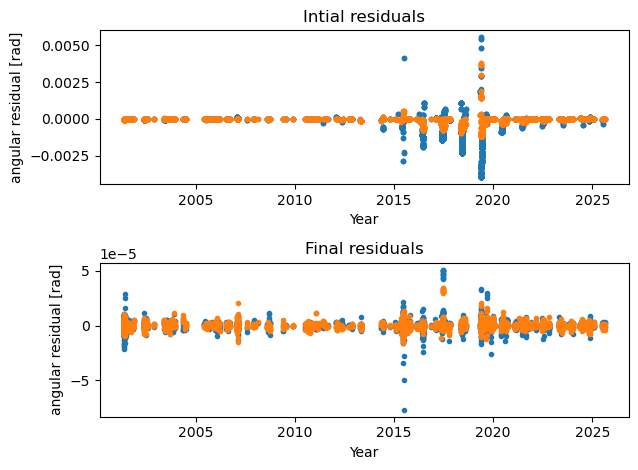

In [33]:
subplot(211)
plot(residual_times[::2], RA_residual_0, '.', label='RA')
plot(residual_times[1::2], Dec_residual_0, '.', label='RA')
xlabel('Year')
ylabel("angular residual [rad]")
title('Intial residuals')

subplot(212)
plot(residual_times[::2], RA_residual_final, '.', label='RA')
plot(residual_times[1::2], Dec_residual_final, '.', label='RA')
xlabel('Year')
ylabel("angular residual [rad]")
title('Final residuals')
     
tight_layout()

In [34]:
reference_states_i = []
index_list = []

print(target_mpc_code)

for i, ast_name in enumerate(target_mpc_code):    
    print(i, ast_name)
    horizonq = HorizonsQuery(
                query_id=f"{ast_name};",
                location=f"500@{global_frame_origin}",
                epoch_list=list(times_get_eph),
                extended_query=True,
            )

    ref = horizonq.cartesian(
                frame_orientation=global_frame_orientation,
                aberations='geometric'
            )[:, 1:]
    
    index_list.append(i)
    reference_states_i.append(ref)

[1566, 66146, 66391, 364136]
0 1566
1 66146
2 66391
3 364136


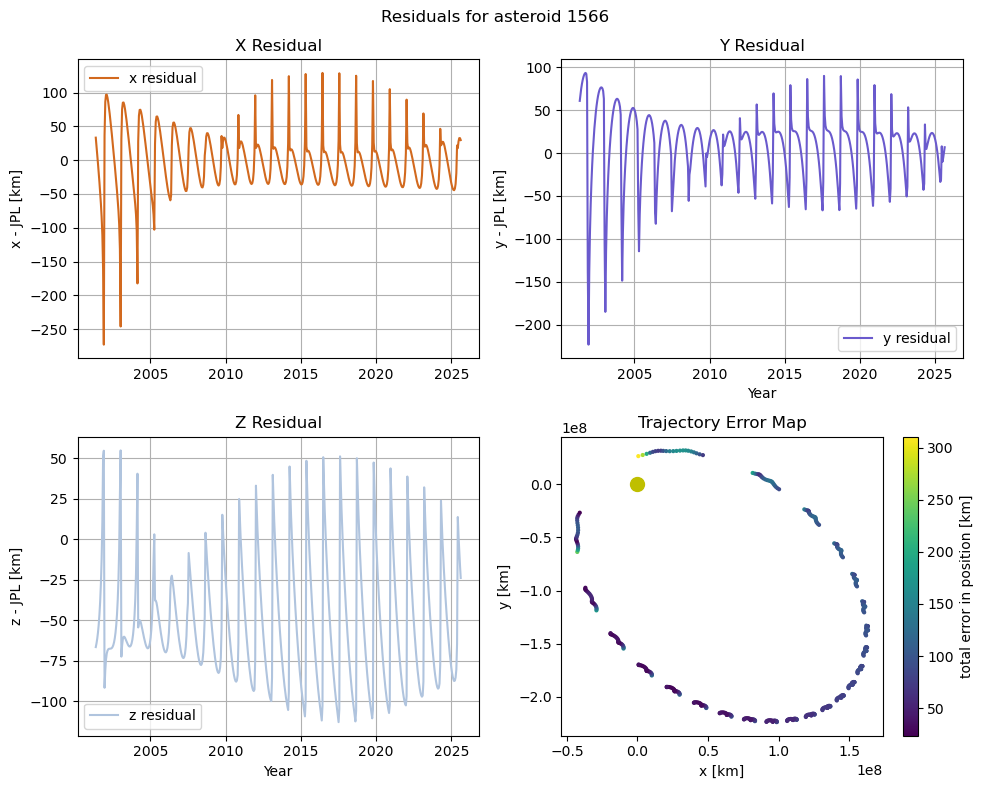

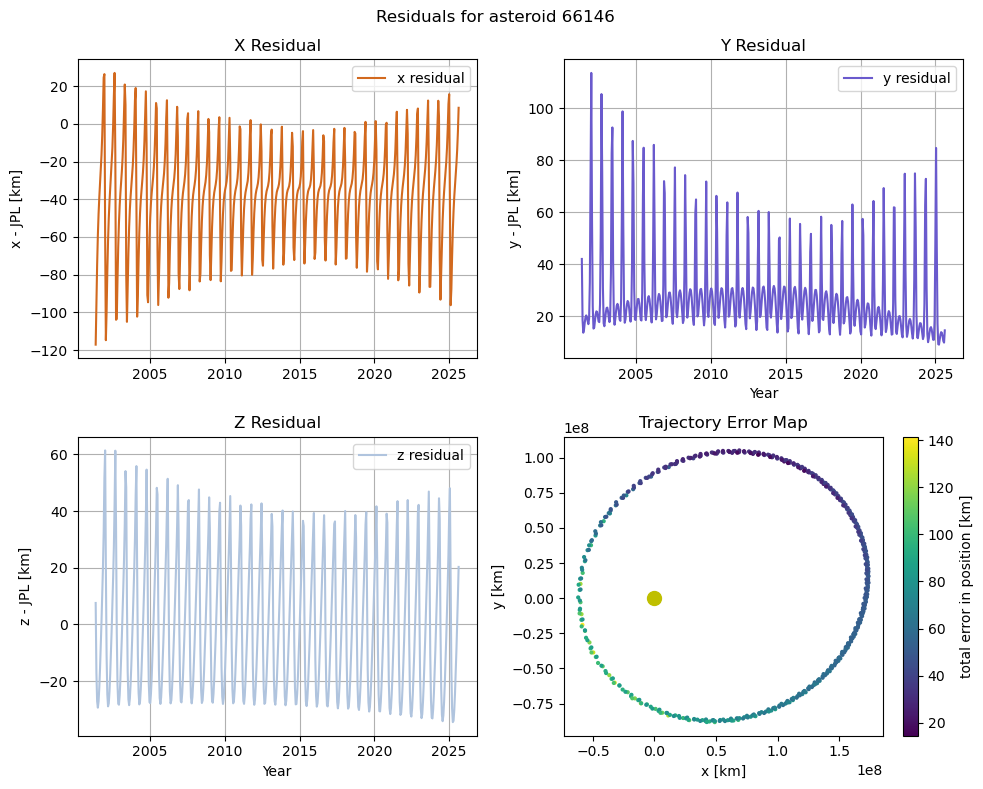

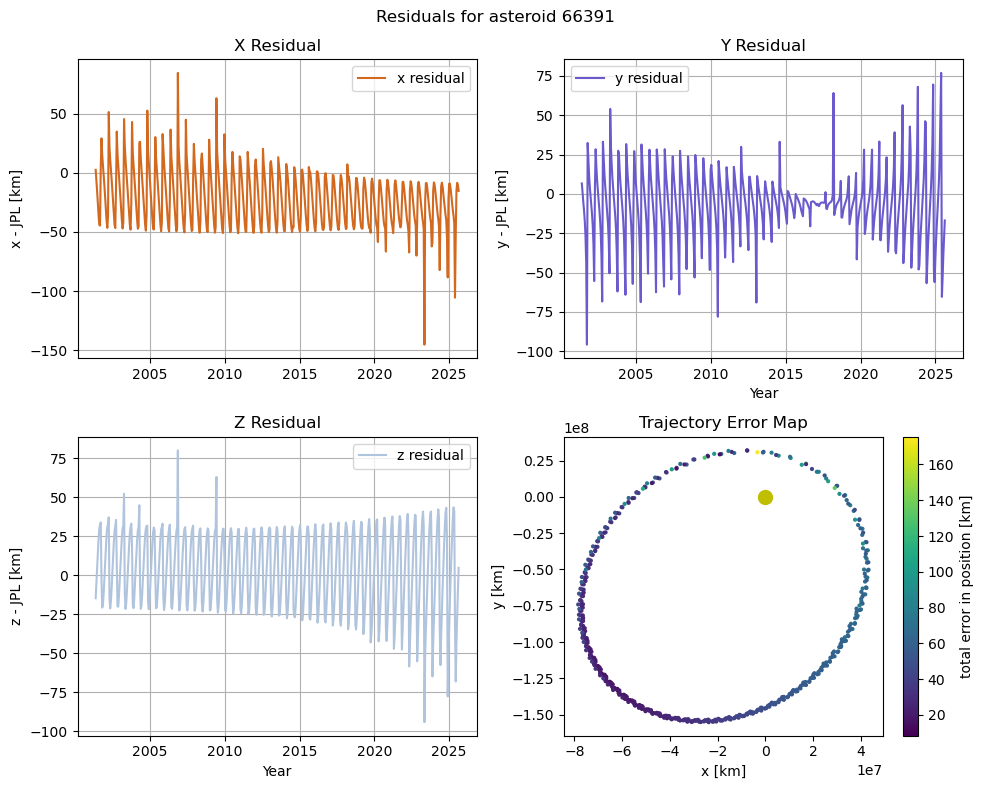

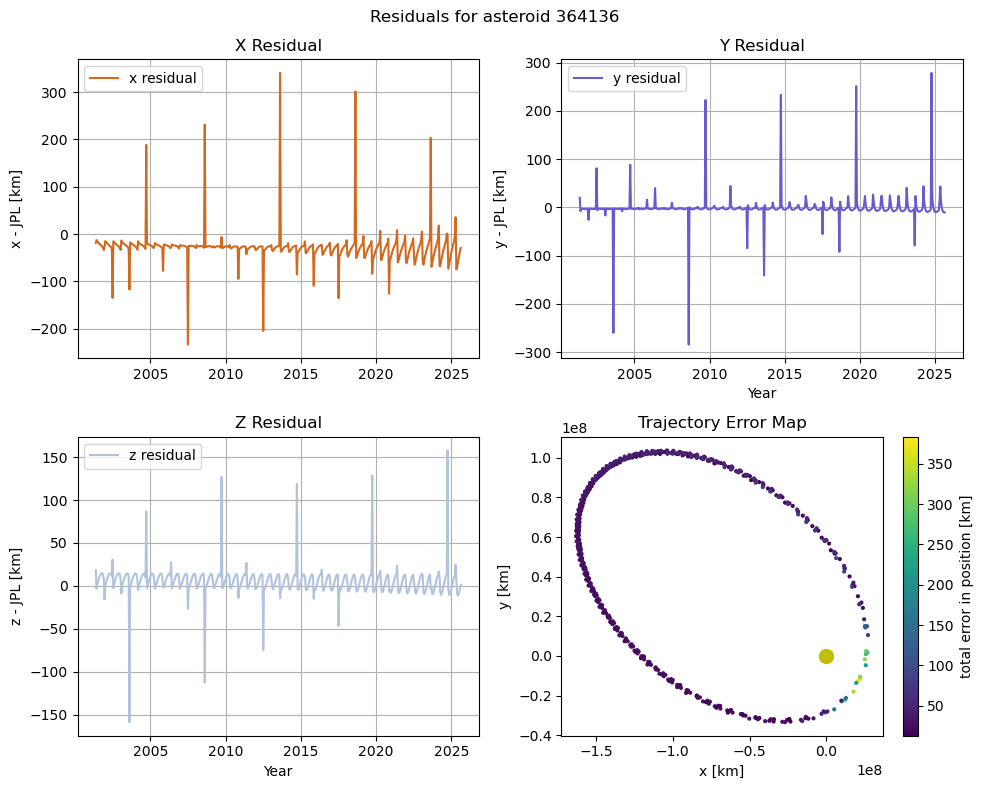

In [35]:
for i, ref_state in zip(index_list, reference_states_i):

    times_plot = times_get_eph / (86400 * 365.25) + 2000

    error_to_reference_i = (
        reference_states_i[i]
        - np.array(state_estimates[target_mpc_code[i]])
    ) / 1000  # km

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    # X residual
    axs[0, 0].plot(
        times_plot,
        error_to_reference_i[:, 0],
        color='chocolate',
        label='x residual'
    )
    axs[0, 0].set_title('X Residual')
    axs[0, 0].set_ylabel('x - JPL [km]')
    axs[0, 0].legend()
    axs[0, 0].grid()

    # Y residual
    axs[0, 1].plot(
        times_plot,
        error_to_reference_i[:, 1],
        color='slateblue',
        label='y residual'
    )
    axs[0, 1].set_title('Y Residual')
    axs[0, 1].set_ylabel('y - JPL [km]')
    axs[0, 1].set_xlabel('Year')
    axs[0, 1].legend()
    axs[0, 1].grid()

    # Z residual
    axs[1, 0].plot(
        times_plot,
        error_to_reference_i[:, 2],
        color='lightsteelblue',
        label='z residual'
    )
    axs[1, 0].set_title('Z Residual')
    axs[1, 0].set_ylabel('z - JPL [km]')
    axs[1, 0].set_xlabel('Year')
    axs[1, 0].legend()
    axs[1, 0].grid()

    # XY trajectory colored by total position error
    ee = state_estimates[target_mpc_code[i]]

    sc = axs[1, 1].scatter(
        ee[:, 0] / 1000,
        ee[:, 1] / 1000,
        c=np.linalg.norm(error_to_reference_i, axis=1),
        s=4
    )

    axs[1, 1].plot(0, 0, 'yo', ms=10)
    axs[1, 1].set_title('Trajectory Error Map')
    axs[1, 1].set_xlabel('x [km]')
    axs[1, 1].set_ylabel('y [km]')

    cb = fig.colorbar(sc, ax=axs[1, 1])
    cb.set_label('total error in position [km]')

    fig.suptitle(f'Residuals for asteroid {target_mpc_code[i]}')

    plt.tight_layout()
    plt.show()

In [36]:
# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input = estimation_analysis.CovarianceAnalysisInput(observation_collection)
covariance_output = estimator.compute_covariance(covariance_input)

correlations = covariance_output.correlations

Calculating residuals and partials 13900


In [37]:
# Create a function to generate the axes of the covariance matrix

def build_estimated_param_names(mpc_target_asteroid):
    base_names = ["x", "y", "z", "vx", "vy", "vz"]

    estimated_param_names = []

    # repeat state block for each asteroid
    for i, ID_i in enumerate(mpc_target_asteroid, start=1):
        state_block = [f"{name}_{ID_i}" for name in base_names]
        estimated_param_names.extend(state_block)

    # add global parameters (only once)
    estimated_param_names += [f"A_2_{i}" for i in mpc_target_asteroid]

    # add global parameters (only once)
    estimated_param_names += ["J2", "Beta-1"]

    return estimated_param_names


estimated_param_names = build_estimated_param_names(target_mpc_code)

print(estimated_param_names)

['x_1566', 'y_1566', 'z_1566', 'vx_1566', 'vy_1566', 'vz_1566', 'x_66146', 'y_66146', 'z_66146', 'vx_66146', 'vy_66146', 'vz_66146', 'x_66391', 'y_66391', 'z_66391', 'vx_66391', 'vy_66391', 'vz_66391', 'x_364136', 'y_364136', 'z_364136', 'vx_364136', 'vy_364136', 'vz_364136', 'A_2_1566', 'A_2_66146', 'A_2_66391', 'A_2_364136', 'J2', 'Beta-1']


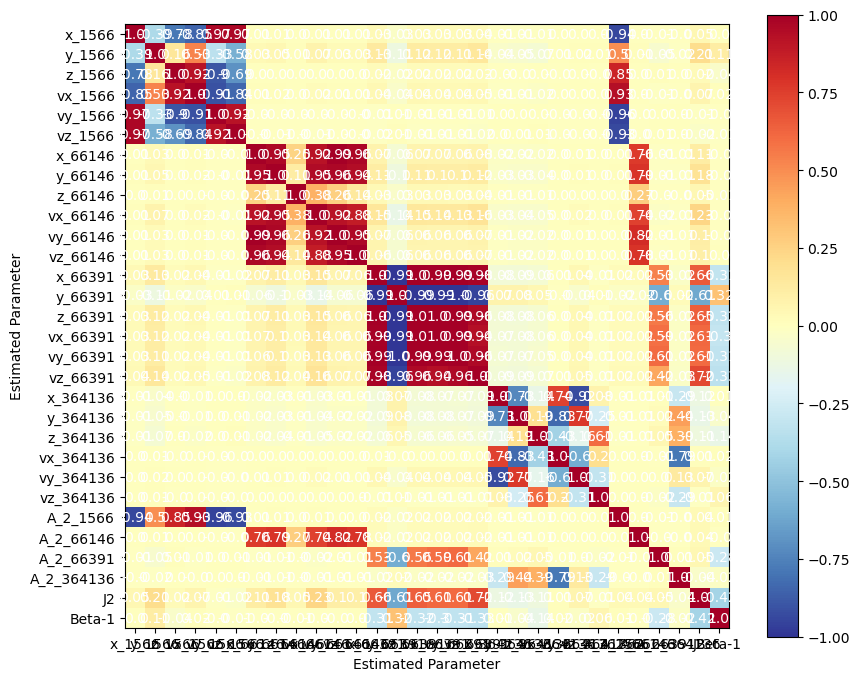

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

im = ax.imshow(correlations, cmap=cm.RdYlBu_r, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)
ax.set_yticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)

# add numbers to each of the boxes
for i in range(len(estimated_param_names)):
    for j in range(len(estimated_param_names)):
        text = ax.text(
            j, i, round(correlations[i, j], 2), ha="center", va="center", color="w"
        )

cb = plt.colorbar(im)

ax.set_xlabel("Estimated Parameter")
ax.set_ylabel("Estimated Parameter")

#fig.suptitle(f"Correlations for estimated parameters for {target_name}")

fig.set_tight_layout(True)

In [39]:
print(len(correlations))
print(correlations.size)
# print(correlations)
print(covariance_output.formal_errors)
# print(covariance_output.weighted_design_matrix)

30
900
[6.19753090e+04 1.56056393e+04 3.57081742e+04 3.67987572e-03
 8.03822543e-03 5.40709923e-03 4.40738626e+04 1.72275701e+04
 1.06833140e+04 3.43064318e-03 1.42381670e-02 5.43707340e-03
 4.25747054e+04 4.34200195e+04 2.67840951e+04 6.42033957e-02
 6.63709273e-02 4.66684249e-02 1.45640146e+04 2.61720551e+04
 1.89931418e+04 7.17747174e-03 4.68715067e-03 1.96463909e-03
 1.35522655e-13 7.32220343e-14 8.48145420e-14 6.86150503e-14
 1.18945221e-02 4.00979155e-07]


In [40]:
1 / ((0.1 / (3600))**2)

1295999999.9999998

# Manually adding stellar occultations

Note: I begin by adding simulated stellar occultations for one asteroid. These steps are shown in depth. Then I merge this simulated stellar occultation with the data from MPC. 
I examine each uncertainty by hand and then I add them to a personal file, this is how I will create the list at the bottom to compare errors.

I begin by examining stellar occultations of one asteroid, and then test what the difference is if I add several occultations at different times for that asteroid.
Further down I also experiment how the uncertainties on beta and J2 change when I add one occultation for several asteroids.

### Adding the first asteroid (for stellar occultations)

In [41]:
# Step 0 of Stellar Occult.: Add a ground station
# I am following the Covariance Analysis with DELFI-C3 and add the observer in Delft, Netherlands

# Define the position of the ground station on Earth
station_altitude = 0.0
delft_latitude = np.deg2rad(52.00667)
delft_longitude = np.deg2rad(4.35556)

# Add the ground station to the environment
environment_setup.add_ground_station(
    bodies.get_body("Earth"),
    "TrackingStation",              # Important, name it correctly
    [station_altitude, delft_latitude, delft_longitude],
    element_conversion.geodetic_position_type)

In [42]:
# 1. Create the links and receiver/ transmitters

from tudatpy.estimation.observations_setup import observations_simulation_settings
from tudatpy.estimation.observable_models_setup import links
# from tudatpy.estimation.observable_models_setup import model_settings
from tudatpy.astro.time_representation import Time

one_way_tracking_ast_link_ends = dict()
one_way_tracking_ast_link_ends[links.transmitter] = links.body_origin_link_end_id("66391")
one_way_tracking_ast_link_ends[links.receiver] = links.body_reference_point_link_end_id("Earth", "TrackingStation")
one_way_tracking_ast_link_definition = links.link_definition(one_way_tracking_ast_link_ends)

# 0 is at J2000

# Because my observations start on the 1st of Jan 2001
one_year_seconds = 365.25 * 24 * 3600 
# This time below will be at J2003
time_1 = 17 * one_year_seconds + 10

# I picked times for Icarus which were scattered when there were few observations
# time_2 = 16 * one_year_seconds + 10
# time_3 = 16 * one_year_seconds + 10
# time_4 = 16 * one_year_seconds + 10

# observation_times = [time_1, time_2, time_3]
observation_times = [time_1]

In [43]:
# Defining the times when each asteroid occults:

# Because my observations start on the 1st of Jan 2001 (that means that we need to account for when the asteroids first appear in batch in the code.)
# for further reasoning see epoch_start_buffer and epoch_start_nobuffer
one_year_seconds = 365.25 * 24 * 3600 

time_1_2_occult = 17 * one_year_seconds + 10
time_1_3_occult = 17 * one_year_seconds + 10
time_1_4_occult = 17 * one_year_seconds + 10
time_1_5_occult = 17 * one_year_seconds + 10
time_1_6_occult = 17 * one_year_seconds + 10

time_1_7_occult = 17 * one_year_seconds + 10
time_1_8_occult = 17 * one_year_seconds + 10
time_1_9_occult = 17 * one_year_seconds + 10
time_1_10_occult = 17 * one_year_seconds + 10

In [44]:
# 2. Create an observation model settings
# (Needed for observation_simulators)
# Defines WHAT is actually observed/ measured

occultation_observation_settings_list = [
    observable_models_setup.model_settings.angular_position(
        one_way_tracking_ast_link_definition
    )
]

type(occultation_observation_settings_list[0])

tudatpy.kernel.estimation.observable_models_setup.model_settings.ObservationModelSettings

In [45]:
# 3. Create the observation simulator objects (with the function create_observation_simulators()
# Tells the code HOW to compute the observable numerically

# (Needed for observation_simulators)

observation_simulators = observations_simulation_settings.create_observation_simulators(occultation_observation_settings_list, bodies)

In [46]:
# 3.75 .
# Moved this down
# WHEN and HOW the measuremenets are taken

# Define the observable_type to be angular for stellar occultations
# I define the observation to be that of an angular_position (since the measurements are made in RA and DEC)
occultation_observable_type = observable_models_setup.model_settings.angular_position_type


observation_simulation_settings = observations_simulation_settings.tabulated_simulation_settings(
    occultation_observable_type,
    one_way_tracking_ast_link_definition,
    observation_times,
    reference_link_end_type=links.receiver      # is this receiver or transmitter?
)

In [47]:
# 2. Add noise to the data

# 1. Define noise level (using the dominant uncertainty for the scalar definition)
sigma_dec_mili_arcsec = 1.0 
sigma_noise_rad = np.deg2rad(sigma_dec_mili_arcsec / (3600.0 * 1000.0))    #Make an explicit float scalar

# 2. Inject the noise 
# Note: This code adds noise to observation_simulation_settings
observations_setup.random_noise.add_gaussian_noise_to_observable(
    [observation_simulation_settings],
    sigma_noise_rad,                  # Passed as a single float scalar
    occultation_observable_type
)

In [48]:
# 4. Simulate the observations

from tudatpy.estimation.observations_setup.observations_wrapper import simulate_observations

simulated_observations = simulate_observations(
    [observation_simulation_settings],
    observation_simulators,
    bodies
)

In [49]:
# 5. Add the weights (I've chosen to add constant weights to any stellar occultation I simulate)

In [50]:
weight1 = 1.0 / (sigma_noise_rad ** 2)
weight2 = 1.0 / (sigma_noise_rad**2)      # larger than the 1st weight
# weight3 = 1.0 / (sigma_noise_rad * 2)**2        # much smaller of the 1st weight

# # # Constant weight
# # simulated_observations.set_constant_weight(
# #     weight)
# n = len(simulated_observations.concatenated_observations)
# tabulated_weights = np.full(n, weight1)


# Set weights for the entire collection
tabulated_weights = np.array([
    weight1, weight1,   # RA1, DEC1
    # weight2, weight2,   # RA2, DEC2
    # weight3, weight3    # RA3, DEC3
])

# tabulated_weights = np.array([
#     weight1,
#     weight2,
#     weight3
# ])

print(tabulated_weights.shape)
simulated_observations.set_tabulated_weights(tabulated_weights)

(2,)


In [51]:
# weight3

In [52]:
print(len(simulated_observations.concatenated_weights))
print(simulated_observations.concatenated_weights)
print(simulated_observations.get_residuals)
print(simulated_observations.set_tabulated_weights)
print(simulated_observations.concatenated_observations)

2
[4.25451703e+16 4.25451703e+16]
<bound method pybind11_detail_function_record_v1_system_libstdcpp_gxx_abi_1xxx_use_cxx11_abi_1.get_residuals of <tudatpy.kernel.estimation.observations.ObservationCollection object at 0x7533743d4870>>
<bound method pybind11_detail_function_record_v1_system_libstdcpp_gxx_abi_1xxx_use_cxx11_abi_1.set_tabulated_weights of <tudatpy.kernel.estimation.observations.ObservationCollection object at 0x7533743d4870>>
[-1.47661374 -0.24267436]


In [53]:
# 6. Merge the simulated observations with the MPC observtions

combined_observation_collection = observations.merge_observation_collections(
        [observation_collection, simulated_observations]
    )

In [54]:
# Pre-7 step: Combine the Observation Models for MPC and Stellar Occultations 
# So that it can be used in the estimaotr
# Otherwise the bodies won't be found when creating the covariance_output
 
observation_settings_list_comb = []

# MPC
for link in link_list:
    observation_settings_list_comb.append(
        observable_models_setup.model_settings.angular_position(link)
    )

# Occultation (add separately)
observation_settings_list_comb.append(
    observable_models_setup.model_settings.angular_position(one_way_tracking_ast_link_definition)
)

# Define a new estimator
estimator_stell_occult = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list_comb,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

In [55]:
# 7. Analyse covariance, correlations etc. with the new simulated data

# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input_occult = estimation_analysis.CovarianceAnalysisInput(combined_observation_collection)
covariance_output_occult = estimator_stell_occult.compute_covariance(covariance_input_occult)

correlations_occult = covariance_output_occult.correlations

Calculating residuals and partials 13902


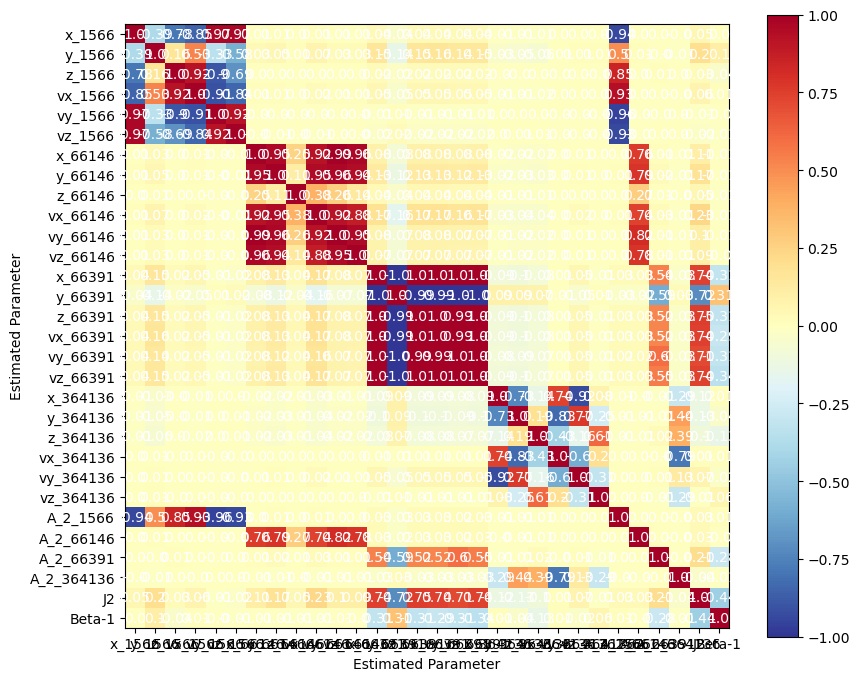

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

im = ax.imshow(correlations_occult, cmap=cm.RdYlBu_r, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)
ax.set_yticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)

# add numbers to each of the boxes
for i in range(len(estimated_param_names)):
    for j in range(len(estimated_param_names)):
        text = ax.text(
            j, i, round(correlations_occult[i, j], 2), ha="center", va="center", color="w"
        )

cb = plt.colorbar(im)

ax.set_xlabel("Estimated Parameter")
ax.set_ylabel("Estimated Parameter")

#fig.suptitle(f"Correlations for estimated parameters for {target_name}")

fig.set_tight_layout(True)

In [57]:
# covariance_output_occult.correlations
print(covariance_output_occult.covariance[-1])
print()

print("Formal errors before stellar occultations")
print(covariance_output.formal_errors)
print('---------------------------------------------')
print("Formal errors after stellar occultations")
print(covariance_output_occult.formal_errors)

diff_covariance = covariance_output.formal_errors - covariance_output_occult.formal_errors

print()
print('----------------------------------------------')
# print('Using NOISE of 1*10**3 mas')
print("Difference between formal errors before and after 1 stellar occultation is added")
print(diff_covariance)

[ 5.63208777e-05  6.39648291e-04 -5.45246919e-04  1.95982766e-11
 -5.57257490e-12 -2.87818518e-11 -9.20347449e-05 -4.00442105e-05
 -3.72223192e-05 -1.27053079e-11 -3.13621331e-11 -3.37159548e-13
 -4.88769650e-03  4.96025268e-03 -3.08723219e-03 -6.70953806e-09
 -7.50380292e-09 -6.11586138e-09  4.96182308e-05 -3.64837470e-04
 -1.00480469e-03  4.25340032e-11 -4.44814520e-11  4.43565909e-11
  4.50105281e-22 -6.89225305e-23 -6.93268584e-21 -4.06291264e-22
 -2.07900831e-09  1.58770515e-13]

Formal errors before stellar occultations
[6.19753090e+04 1.56056393e+04 3.57081742e+04 3.67987572e-03
 8.03822543e-03 5.40709923e-03 4.40738626e+04 1.72275701e+04
 1.06833140e+04 3.43064318e-03 1.42381670e-02 5.43707340e-03
 4.25747054e+04 4.34200195e+04 2.67840951e+04 6.42033957e-02
 6.63709273e-02 4.66684249e-02 1.45640146e+04 2.61720551e+04
 1.89931418e+04 7.17747174e-03 4.68715067e-03 1.96463909e-03
 1.35522655e-13 7.32220343e-14 8.48145420e-14 6.86150503e-14
 1.18945221e-02 4.00979155e-07]
---------

Formal errors before stellar occultations
[3.14454371e+04 3.28611012e+04 3.37207414e+04 1.26533947e-03
 1.35140893e-03 1.22644945e-03 2.66144498e+04 4.26945923e+04
 1.92684696e+04 2.58940445e-02 1.78466550e-02 8.68099057e-03
 6.62914055e-02 3.30074411e-06]
---------------------------------------------
Formal errors after stellar occultations
[3.01328889e+04 3.26863534e+04 3.31896091e+04 1.21042241e-03
 1.33790970e-03 1.22568544e-03 7.98204404e+03 1.62899929e+04
 7.34497972e+03 6.11967022e-03 6.36695559e-03 2.21490558e-03
 6.21733727e-02 3.17190721e-06]

----------------------------------------------
Difference between formal errors before and after stellar occultations are added
[1.31254822e+03 1.74747797e+02 5.31132332e+02 5.49170694e-05
 1.34992239e-05 7.64007824e-07 1.86324058e+04 2.64045994e+04
 1.19234898e+04 1.97743743e-02 1.14796994e-02 6.46608499e-03
 4.11803284e-03 1.28836896e-07]

In [58]:
# [1.31549637e+03 1.75158731e+02 5.32304904e+02 5.50403646e-05
#  1.35288663e-05 7.66241425e-07 1.87688714e+04 2.65779770e+04
#  1.19875697e+04 1.99491719e-02 1.15446746e-02 6.58680505e-03
#  4.12732570e-03 1.29124590e-07]

## Adding the second asteroid for stellar occultations

In [59]:
from tudatpy.estimation.observations_setup import observations_simulation_settings
from tudatpy.estimation.observable_models_setup import links
from tudatpy.astro.time_representation import Time
from tudatpy.estimation.observations_setup.observations_wrapper import simulate_observations

# 0. I keep the ground station the same for now:

def simulate_stellar_occultation(ast_name, tracking_name, times_list):
  
    """A function to simulate stellar occultations (as an angular type)"""

    # 1. Create the links and receiver/ transmitters
    tracking_ast_link_end_2 = dict()
    tracking_ast_link_end_2[links.transmitter] = links.body_origin_link_end_id(ast_name)
    tracking_ast_link_end_2[links.receiver] = links.body_reference_point_link_end_id("Earth", tracking_name)
    tracking_ast_link_definition_2 = links.link_definition(tracking_ast_link_end_2)

    # 2. Create an observation model settings
    # (Needed for observation_simulators)
    # Defines WHAT is actually observed/ measured

    occultation_observation_settings_list_2 = [
        observable_models_setup.model_settings.angular_position(
            tracking_ast_link_definition_2
        )
    ]

    # 3. Create the observation simulator objects (with the function create_observation_simulators()
    # Tells the code HOW to compute the observable numerically
    # (Needed for observation_simulators)

    observation_simulators_2 = observations_simulation_settings.create_observation_simulators(occultation_observation_settings_list_2, bodies)


    # 4. Define WHEN and HOW the measuremenets are taken

    # Define the observable_type to be angular for stellar occultations
    # I define the observation to be that of an angular_position (since the measurements are made in RA and DEC)
    occultation_observable_type = observable_models_setup.model_settings.angular_position_type


    observation_simulation_settings_2 = observations_simulation_settings.tabulated_simulation_settings(
        occultation_observable_type,
        tracking_ast_link_definition_2,
        times_list,
        reference_link_end_type=links.receiver      # this is set to be receiver (see Tudat forum discussion)
    )

    # 5. Add noise to the data

    # 5i. Define noise level (using the dominant uncertainty for the scalar definition)
    sigma_dec_mili_arcsec_i = 1.0 
    sigma_noise_rad_i = np.deg2rad(sigma_dec_mili_arcsec_i / (3600.0 * 1000.0))    #Make an explicit float scalar

    # 5ii. Inject the noise 
    # Note: This code adds noise to observation_simulation_settings
    observations_setup.random_noise.add_gaussian_noise_to_observable(
        [observation_simulation_settings_2],
        sigma_noise_rad_i,                  # Passed as a single float scalar
        occultation_observable_type
    )


    # 6. Simulate the observations

    simulated_observations_2 = simulate_observations(
        [observation_simulation_settings_2],
        observation_simulators_2,
        bodies
    )

    return tracking_ast_link_definition_2, sigma_noise_rad_i, simulated_observations_2

In [60]:
# 7. Simulate the observations and add the weights

times_list_2_occult = [time_1_2_occult]

tracking_ast_link_definition_2_occult, sigma_noise_rad_2_occult, simulated_observations_2_occult = simulate_stellar_occultation("66391", "TrackingStation", times_list_2_occult)

# Create the weights 

weight1_2_occult = 1.0 / (sigma_noise_rad_2_occult ** 2)
weight2_2_occult = 1.0 / ((sigma_noise_rad_2_occult)**2)      # larger than the 1st weight
# weight3 = 1.0 / (sigma_noise_rad * 2)**2        # much smaller of the 1st weight


# Set weights for the entire collection
tabulated_weights_2_occult = np.array([
    weight1, weight1,   # RA1, DEC1
    # weight2, weight2,   # RA2, DEC2
    # weight3, weight3    # RA3, DEC3
])

print(tabulated_weights_2_occult.shape)

# Add the weights
simulated_observations_2_occult.set_tabulated_weights(tabulated_weights_2_occult)

(2,)


In [61]:
# 8. Merge together with previous observations

combined_observation_collection_2_occult = observations.merge_observation_collections(
        [combined_observation_collection, simulated_observations_2_occult]
    )

In [62]:
# Pre-7 step: Combine the Observation Models for MPC and Stellar Occultations 
# So that it can be used in the estimaotr
# Otherwise the bodies won't be found when creating the covariance_output
 
observation_settings_list_comb_2_occult = []

# MPC
for link in link_list:
    observation_settings_list_comb_2_occult.append(
        observable_models_setup.model_settings.angular_position(link)
    )

# 1st occultation
observation_settings_list_comb_2_occult.append(
    observable_models_setup.model_settings.angular_position(one_way_tracking_ast_link_definition)
)

# 2nd occultation
observation_settings_list_comb_2_occult.append(
    observable_models_setup.model_settings.angular_position(tracking_ast_link_definition_2_occult)
)

# Define a new estimator
estimator_stell_occult_2 = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list_comb_2_occult,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

In [63]:
# 7. Analyse covariance, correlations etc. with the new simulated data

# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input_occult_2 = estimation_analysis.CovarianceAnalysisInput(combined_observation_collection_2_occult)
covariance_output_occult_2 = estimator_stell_occult_2.compute_covariance(covariance_input_occult_2)

correlations_occult_2 = covariance_output_occult_2.correlations

Calculating residuals and partials 13904


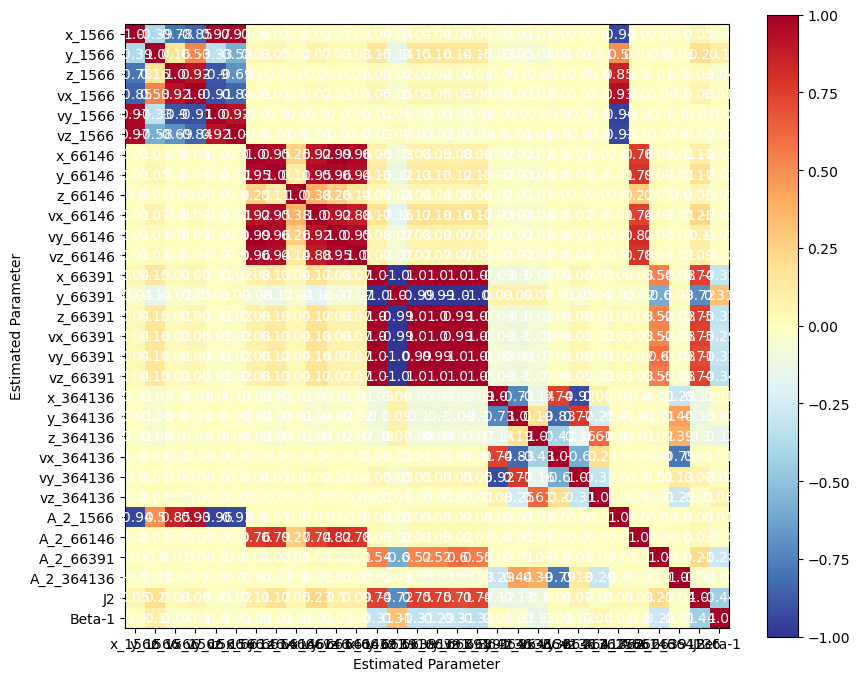

In [64]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

im = ax.imshow(correlations_occult_2, cmap=cm.RdYlBu_r, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)
ax.set_yticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)

# add numbers to each of the boxes
for i in range(len(estimated_param_names)):
    for j in range(len(estimated_param_names)):
        text = ax.text(
            j, i, round(correlations_occult_2[i, j], 2), ha="center", va="center", color="w"
        )

cb = plt.colorbar(im)

ax.set_xlabel("Estimated Parameter")
ax.set_ylabel("Estimated Parameter")

#fig.suptitle(f"Correlations for estimated parameters for {target_name}")

fig.set_tight_layout(True)


In [65]:
# covariance_output_occult.correlations
print(covariance_output_occult_2.covariance[-1])
print()

print("Formal errors before stellar occultations")
print(covariance_output.formal_errors)
print('---------------------------------------------')
print("Formal errors after stellar occultations")
print(covariance_output_occult.formal_errors)
print("Formal errors after 2 stellar occultations")
print(covariance_output_occult_2.formal_errors)

diff_covariance_2 = covariance_output.formal_errors - covariance_output_occult_2.formal_errors

print()
print('----------------------------------------------')
# print('Using NOISE of 1*10**3 mas')
print("Difference between formal errors before and after 2 stellar occultations are added")
print(diff_covariance_2)

[ 5.59753406e-05  6.39161440e-04 -5.45219617e-04  1.95681924e-11
 -5.56051677e-12 -2.87614202e-11 -9.25316075e-05 -4.03602789e-05
 -3.72742546e-05 -1.27880483e-11 -3.15106675e-11 -3.93429384e-13
 -4.88838833e-03  4.96080222e-03 -3.08711502e-03 -6.70809983e-09
 -7.50441412e-09 -6.11921658e-09  4.97952492e-05 -3.64381738e-04
 -1.00436649e-03  4.25178769e-11 -4.45051202e-11  4.43492242e-11
  4.49486389e-22 -6.91830019e-23 -6.91223470e-21 -4.05925153e-22
 -2.07981051e-09  1.58753017e-13]

Formal errors before stellar occultations
[6.19753090e+04 1.56056393e+04 3.57081742e+04 3.67987572e-03
 8.03822543e-03 5.40709923e-03 4.40738626e+04 1.72275701e+04
 1.06833140e+04 3.43064318e-03 1.42381670e-02 5.43707340e-03
 4.25747054e+04 4.34200195e+04 2.67840951e+04 6.42033957e-02
 6.63709273e-02 4.66684249e-02 1.45640146e+04 2.61720551e+04
 1.89931418e+04 7.17747174e-03 4.68715067e-03 1.96463909e-03
 1.35522655e-13 7.32220343e-14 8.48145420e-14 6.86150503e-14
 1.18945221e-02 4.00979155e-07]
---------

### Adding the third stellar occultation

In [66]:
# 7. Simulate the observations and add the weights

times_list_3_occult = [time_1_3_occult]

tracking_ast_link_definition_3_occult, sigma_noise_rad_3_occult, simulated_observations_3_occult = simulate_stellar_occultation("66391", "TrackingStation", times_list_3_occult)

# Create the weights 

weight1_3_occult = 1.0 / (sigma_noise_rad_3_occult ** 2)
weight2_3_occult = 1.0 / ((sigma_noise_rad_3_occult)**2)      # larger than the 1st weight
# weight3 = 1.0 / (sigma_noise_rad * 2)**2        # much smaller of the 1st weight


# Set weights for the entire collection
tabulated_weights_3_occult = np.array([
    weight1_3_occult, weight1_3_occult,   # RA1, DEC1
    # weight2, weight2,   # RA2, DEC2
    # weight3, weight3    # RA3, DEC3
])

print(tabulated_weights_3_occult.shape)

# Add the weights
simulated_observations_3_occult.set_tabulated_weights(tabulated_weights_3_occult)

(2,)


In [67]:
# 8. Merge together with previous observations

combined_observation_collection_3_occult = observations.merge_observation_collections(
        [combined_observation_collection_2_occult, simulated_observations_3_occult]
    )

In [68]:
# 9. Combine the Observation Models for MPC and Stellar Occultations 
# So that it can be used in the estimaotr
# Otherwise the bodies won't be found when creating the covariance_output
 
observation_settings_list_comb_3_occult = []

# MPC
for link in link_list:
    observation_settings_list_comb_3_occult.append(
        observable_models_setup.model_settings.angular_position(link)
    )

# 1st occultation
observation_settings_list_comb_3_occult.append(
    observable_models_setup.model_settings.angular_position(one_way_tracking_ast_link_definition)
)

# 2nd occultation
observation_settings_list_comb_3_occult.append(
    observable_models_setup.model_settings.angular_position(tracking_ast_link_definition_2_occult)
)

# 3rd occultation
observation_settings_list_comb_3_occult.append(
    observable_models_setup.model_settings.angular_position(tracking_ast_link_definition_3_occult)
)

# Define a new estimator
estimator_stell_occult_3 = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list_comb_3_occult,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

In [69]:
# 10. Analyse covariance, correlations etc. with the new simulated data

# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input_occult_3 = estimation_analysis.CovarianceAnalysisInput(combined_observation_collection_3_occult)
covariance_output_occult_3 = estimator_stell_occult_3.compute_covariance(covariance_input_occult_3)

correlations_occult_3 = covariance_output_occult_3.correlations

Calculating residuals and partials 13906


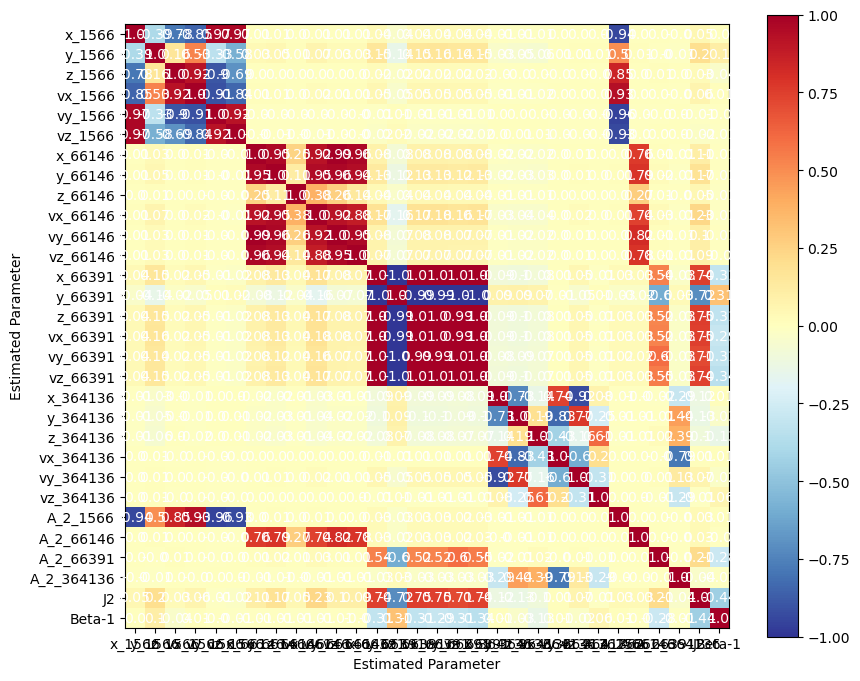

In [70]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

im = ax.imshow(correlations_occult_3, cmap=cm.RdYlBu_r, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)
ax.set_yticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)

# add numbers to each of the boxes
for i in range(len(estimated_param_names)):
    for j in range(len(estimated_param_names)):
        text = ax.text(
            j, i, round(correlations_occult_3[i, j], 2), ha="center", va="center", color="w"
        )

cb = plt.colorbar(im)

ax.set_xlabel("Estimated Parameter")
ax.set_ylabel("Estimated Parameter")

#fig.suptitle(f"Correlations for estimated parameters for {target_name}")

fig.set_tight_layout(True)


In [71]:
# covariance_output_occult.correlations
print(covariance_output_occult_3.covariance[-1])
print()

print("Formal errors before stellar occultations")
print(covariance_output.formal_errors)
print('---------------------------------------------')
print("Formal errors after stellar occultations")
print(covariance_output_occult.formal_errors)
print("Formal errors after 2 asteroids occultating")
print(covariance_output_occult_2.formal_errors)
print("Formal errors after 3 asteroids occultating")
print(covariance_output_occult_2.formal_errors)

diff_covariance_3 = covariance_output.formal_errors - covariance_output_occult_3.formal_errors

print()
print('----------------------------------------------')
# print('Using NOISE of 1*10**3 mas')
print("Difference between formal errors before and after 3 stellar occultations are added")
print(diff_covariance_3)

[ 5.58560204e-05  6.38993753e-04 -5.45210605e-04  1.95578151e-11
 -5.55635565e-12 -2.87543844e-11 -9.27033164e-05 -4.04694936e-05
 -3.72922240e-05 -1.28166402e-11 -3.15620019e-11 -4.12867709e-13
 -4.88869722e-03  4.96107264e-03 -3.08712188e-03 -6.70772579e-09
 -7.50474994e-09 -6.12042902e-09  4.98564373e-05 -3.64224588e-04
 -1.00421589e-03  4.25123389e-11 -4.45133304e-11  4.43467136e-11
  4.49272943e-22 -6.92730332e-23 -6.90529333e-21 -4.05798995e-22
 -2.08008923e-09  1.58747095e-13]

Formal errors before stellar occultations
[6.19753090e+04 1.56056393e+04 3.57081742e+04 3.67987572e-03
 8.03822543e-03 5.40709923e-03 4.40738626e+04 1.72275701e+04
 1.06833140e+04 3.43064318e-03 1.42381670e-02 5.43707340e-03
 4.25747054e+04 4.34200195e+04 2.67840951e+04 6.42033957e-02
 6.63709273e-02 4.66684249e-02 1.45640146e+04 2.61720551e+04
 1.89931418e+04 7.17747174e-03 4.68715067e-03 1.96463909e-03
 1.35522655e-13 7.32220343e-14 8.48145420e-14 6.86150503e-14
 1.18945221e-02 4.00979155e-07]
---------

### Adding a fourth asteroid to perform stellar occultations

I'm now testing asteroids which have large dw values.

In [72]:
# 7. Simulate the observations and add the weights

times_list_4_occult = [time_1_4_occult]

tracking_ast_link_definition_4_occult, sigma_noise_rad_4_occult, simulated_observations_4_occult = simulate_stellar_occultation("66391", "TrackingStation", times_list_4_occult)

# Create the weights 

weight1_4_occult = 1.0 / (sigma_noise_rad_4_occult ** 2)
weight2_4_occult = 1.0 / (sigma_noise_rad_4_occult)**2      # larger than the 1st weight
# weight3 = 1.0 / (sigma_noise_rad * 2)**2        # much smaller of the 1st weight


# Set weights for the entire collection
tabulated_weights_4_occult = np.array([
    weight1_4_occult, weight1_4_occult,   # RA1, DEC1
    # weight2, weight2,   # RA2, DEC2
    # weight3, weight3    # RA3, DEC3
])

print(tabulated_weights_4_occult.shape)

# Add the weights
simulated_observations_4_occult.set_tabulated_weights(tabulated_weights_4_occult)

(2,)


In [73]:
# 8. Merge together with previous observations

combined_observation_collection_4_occult = observations.merge_observation_collections(
        [combined_observation_collection_3_occult, simulated_observations_4_occult]
    )

In [74]:
# 9. Combine the Observation Models for MPC and Stellar Occultations 
# So that it can be used in the estimaotr
# Otherwise the bodies won't be found when creating the covariance_output
 
observation_settings_list_comb_4_occult = []

# MPC
for link in link_list:
    observation_settings_list_comb_4_occult.append(
        observable_models_setup.model_settings.angular_position(link)
    )

# 1st occultation
observation_settings_list_comb_4_occult.append(
    observable_models_setup.model_settings.angular_position(one_way_tracking_ast_link_definition)
)

# 2nd occultation
observation_settings_list_comb_4_occult.append(
    observable_models_setup.model_settings.angular_position(tracking_ast_link_definition_2_occult)
)

# 3rd occultation
observation_settings_list_comb_4_occult.append(
    observable_models_setup.model_settings.angular_position(tracking_ast_link_definition_3_occult)
)

# 4th occultation
observation_settings_list_comb_4_occult.append(
    observable_models_setup.model_settings.angular_position(tracking_ast_link_definition_4_occult)
)

# Define a new estimator
estimator_stell_occult_4 = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list_comb_4_occult,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

In [75]:
# 10. Analyse covariance, correlations etc. with the new simulated data

# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input_occult_4 = estimation_analysis.CovarianceAnalysisInput(combined_observation_collection_4_occult)
covariance_output_occult_4 = estimator_stell_occult_4.compute_covariance(covariance_input_occult_4)

correlations_occult_4 = covariance_output_occult_4.correlations

Calculating residuals and partials 13908


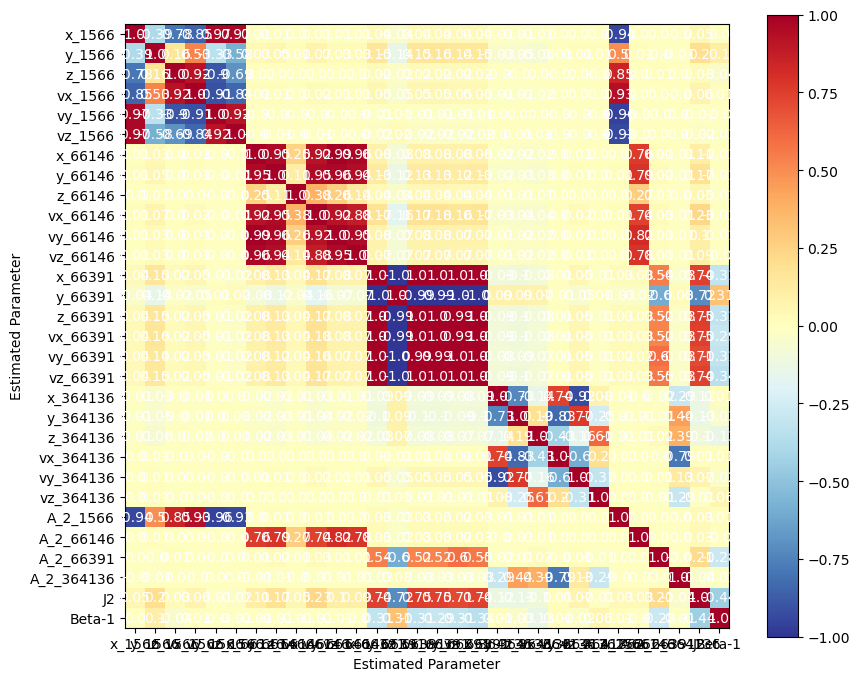

In [76]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

im = ax.imshow(correlations_occult_4, cmap=cm.RdYlBu_r, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)
ax.set_yticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)

# add numbers to each of the boxes
for i in range(len(estimated_param_names)):
    for j in range(len(estimated_param_names)):
        text = ax.text(
            j, i, round(correlations_occult_4[i, j], 2), ha="center", va="center", color="w"
        )

cb = plt.colorbar(im)

ax.set_xlabel("Estimated Parameter")
ax.set_ylabel("Estimated Parameter")

#fig.suptitle(f"Correlations for estimated parameters for {target_name}")

fig.set_tight_layout(True)


In [77]:
# covariance_output_occult.correlations
print(covariance_output_occult_4.covariance[-1])
print()

print("Formal errors before stellar occultations")
print(covariance_output.formal_errors)
print('---------------------------------------------')
print("Formal errors after stellar occultations")
print(covariance_output_occult.formal_errors)
print("Formal errors after 2 asteroids occultating")
print(covariance_output_occult_2.formal_errors)
print("Formal errors after 3 asteroids occultating")
print(covariance_output_occult_3.formal_errors)
print("Formal errors after 4 asteroids occultating")
print(covariance_output_occult_4.formal_errors)

diff_covariance_4 = covariance_output.formal_errors - covariance_output_occult_4.formal_errors

print()
print('----------------------------------------------')
# print('Using NOISE of 1*10**3 mas')
print("Difference between formal errors before and after 4 stellar occultations are added")
print(diff_covariance_4)

[ 5.57825650e-05  6.38895380e-04 -5.45209745e-04  1.95515541e-11
 -5.55382527e-12 -2.87502737e-11 -9.28105230e-05 -4.05375216e-05
 -3.73036823e-05 -1.28344689e-11 -3.15940859e-11 -4.24916671e-13
 -4.88908971e-03  4.96144448e-03 -3.08727148e-03 -6.70787863e-09
 -7.50527778e-09 -6.12130741e-09  4.98947859e-05 -3.64130364e-04
 -1.00413127e-03  4.25092755e-11 -4.45188038e-11  4.43455421e-11
  4.49144569e-22 -6.93294234e-23 -6.90197600e-21 -4.05724336e-22
 -2.08027997e-09  1.58744801e-13]

Formal errors before stellar occultations
[6.19753090e+04 1.56056393e+04 3.57081742e+04 3.67987572e-03
 8.03822543e-03 5.40709923e-03 4.40738626e+04 1.72275701e+04
 1.06833140e+04 3.43064318e-03 1.42381670e-02 5.43707340e-03
 4.25747054e+04 4.34200195e+04 2.67840951e+04 6.42033957e-02
 6.63709273e-02 4.66684249e-02 1.45640146e+04 2.61720551e+04
 1.89931418e+04 7.17747174e-03 4.68715067e-03 1.96463909e-03
 1.35522655e-13 7.32220343e-14 8.48145420e-14 6.86150503e-14
 1.18945221e-02 4.00979155e-07]
---------

### Adding the 5th occultation

In [78]:
# 7. Simulate the observations and add the weights

# observation_times = [time_1, time_2, time_3]
times_list_5_occult = [time_1_5_occult]

tracking_ast_link_definition_5_occult, sigma_noise_rad_5_occult, simulated_observations_5_occult = simulate_stellar_occultation("66391", "TrackingStation", times_list_5_occult)

# Create the weights 

weight1_5_occult = 1.0 / (sigma_noise_rad_5_occult ** 2)
weight2_5_occult = 1.0 / (sigma_noise_rad_5_occult)**2      # larger than the 1st weight
# weight3 = 1.0 / (sigma_noise_rad * 2)**2        # much smaller of the 1st weight


# Set weights for the entire collection
tabulated_weights_5_occult = np.array([
    weight1_5_occult, weight1_5_occult,   # RA1, DEC1
    # weight2, weight2,   # RA2, DEC2
    # weight3, weight3    # RA3, DEC3
])

print(tabulated_weights_5_occult.shape)

# Add the weights
simulated_observations_5_occult.set_tabulated_weights(tabulated_weights_5_occult)

(2,)


In [79]:
# 8. Merge together with previous observations

combined_observation_collection_5_occult = observations.merge_observation_collections(
        [combined_observation_collection_4_occult, simulated_observations_5_occult]
    )

In [80]:
# 9. Create the links

occultation_links = [
    one_way_tracking_ast_link_definition,
    tracking_ast_link_definition_2_occult,
    tracking_ast_link_definition_3_occult,
    tracking_ast_link_definition_4_occult,
    tracking_ast_link_definition_5_occult
]

observation_settings_list_comb_5_occult = [
    observable_models_setup.model_settings.angular_position(link)
    for link in list(link_list) + occultation_links
]

estimator_stell_occult_5 = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list_comb_5_occult,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

# 10. Analyse covariance, correlations etc. with the new simulated data

# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input_occult_5 = estimation_analysis.CovarianceAnalysisInput(combined_observation_collection_5_occult)
covariance_output_occult_5 = estimator_stell_occult_5.compute_covariance(covariance_input_occult_5)

correlations_occult_5 = covariance_output_occult_5.correlations

Calculating residuals and partials 13910


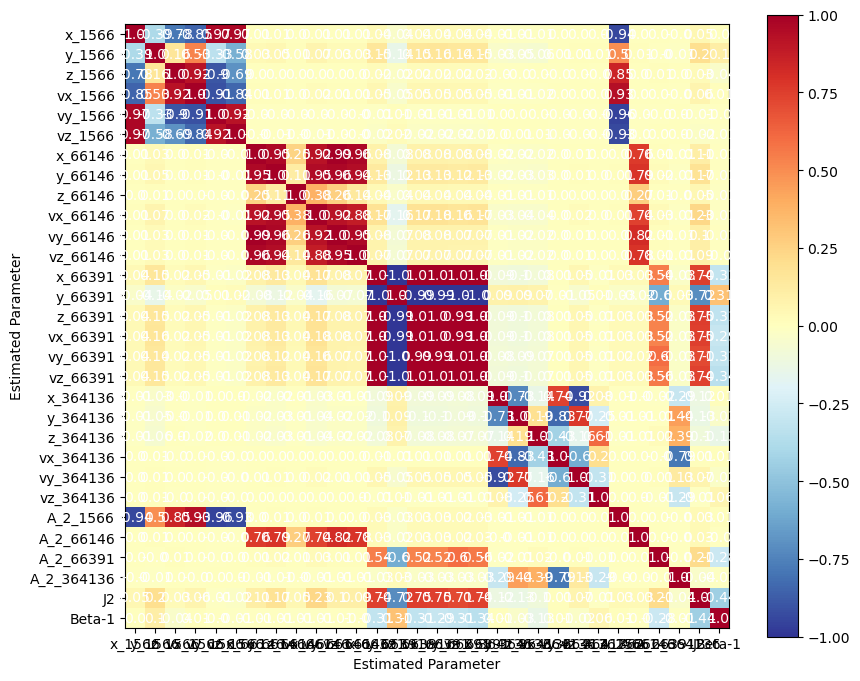

In [81]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

im = ax.imshow(correlations_occult_5, cmap=cm.RdYlBu_r, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)
ax.set_yticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)

# add numbers to each of the boxes
for i in range(len(estimated_param_names)):
    for j in range(len(estimated_param_names)):
        text = ax.text(
            j, i, round(correlations_occult_5[i, j], 2), ha="center", va="center", color="w"
        )

cb = plt.colorbar(im)

ax.set_xlabel("Estimated Parameter")
ax.set_ylabel("Estimated Parameter")

#fig.suptitle(f"Correlations for estimated parameters for {target_name}")

fig.set_tight_layout(True)


In [82]:
# covariance_output_occult.correlations
print(covariance_output_occult_4.covariance[-1])
print()

print("Formal errors before stellar occultations")
print(covariance_output.formal_errors)
print('---------------------------------------------')
print("Formal errors after stellar occultations")
print(covariance_output_occult.formal_errors)
print("Formal errors after 2 asteroids occultating")
print(covariance_output_occult_2.formal_errors)
print("Formal errors after 3 asteroids occultating")
print(covariance_output_occult_3.formal_errors)
print("Formal errors after 4 asteroids occultating")
print(covariance_output_occult_4.formal_errors)
print("Formal errors after 5 asteroids occultating")
print(covariance_output_occult_5.formal_errors)

diff_covariance_5 = covariance_output.formal_errors - covariance_output_occult_5.formal_errors

print()
print('----------------------------------------------')
# print('Using NOISE of 1*10**3 mas')
print("Difference between formal errors before and after 5 stellar occultations are added")
print(diff_covariance_5)

[ 5.57825650e-05  6.38895380e-04 -5.45209745e-04  1.95515541e-11
 -5.55382527e-12 -2.87502737e-11 -9.28105230e-05 -4.05375216e-05
 -3.73036823e-05 -1.28344689e-11 -3.15940859e-11 -4.24916671e-13
 -4.88908971e-03  4.96144448e-03 -3.08727148e-03 -6.70787863e-09
 -7.50527778e-09 -6.12130741e-09  4.98947859e-05 -3.64130364e-04
 -1.00413127e-03  4.25092755e-11 -4.45188038e-11  4.43455421e-11
  4.49144569e-22 -6.93294234e-23 -6.90197600e-21 -4.05724336e-22
 -2.08027997e-09  1.58744801e-13]

Formal errors before stellar occultations
[6.19753090e+04 1.56056393e+04 3.57081742e+04 3.67987572e-03
 8.03822543e-03 5.40709923e-03 4.40738626e+04 1.72275701e+04
 1.06833140e+04 3.43064318e-03 1.42381670e-02 5.43707340e-03
 4.25747054e+04 4.34200195e+04 2.67840951e+04 6.42033957e-02
 6.63709273e-02 4.66684249e-02 1.45640146e+04 2.61720551e+04
 1.89931418e+04 7.17747174e-03 4.68715067e-03 1.96463909e-03
 1.35522655e-13 7.32220343e-14 8.48145420e-14 6.86150503e-14
 1.18945221e-02 4.00979155e-07]
---------

### Adding the 6th asteroid occultation

In [83]:
# 7. Simulate the observations and add the weights

times_list_6_occult = [time_1_6_occult]

tracking_ast_link_definition_6_occult, sigma_noise_rad_6_occult, simulated_observations_6_occult = simulate_stellar_occultation("66391", "TrackingStation", times_list_6_occult)

# Create the weights

weight1_6_occult = 1.0 / (sigma_noise_rad_6_occult ** 2)
weight2_6_occult = 1.0 / (sigma_noise_rad_6_occult)**2      # larger than the 1st weight
# weight3 = 1.0 / (sigma_noise_rad * 2)**2        # much smaller of the 1st weight


# Set weights for the entire collection
tabulated_weights_6_occult = np.array([
    weight1_6_occult, weight1_6_occult,   # RA1, DEC1
    # weight2, weight2,   # RA2, DEC2
    # weight3, weight3    # RA3, DEC3
])

print(tabulated_weights_6_occult.shape)

# Add the weights
simulated_observations_6_occult.set_tabulated_weights(tabulated_weights_6_occult)


# 8. Merge together with previous observations

combined_observation_collection_6_occult = observations.merge_observation_collections(
        [combined_observation_collection_5_occult, simulated_observations_6_occult]
    )


# 9. Create the links

occultation_links = [
    one_way_tracking_ast_link_definition,
    tracking_ast_link_definition_2_occult,
    tracking_ast_link_definition_3_occult,
    tracking_ast_link_definition_4_occult,
    tracking_ast_link_definition_5_occult,
    tracking_ast_link_definition_6_occult
]

observation_settings_list_comb_6_occult = [
    observable_models_setup.model_settings.angular_position(link)
    for link in list(link_list) + occultation_links
]

estimator_stell_occult_6 = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list_comb_6_occult,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

# 10. Analyse covariance, correlations etc. with the new simulated data

# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input_occult_6 = estimation_analysis.CovarianceAnalysisInput(combined_observation_collection_6_occult)
covariance_output_occult_6 = estimator_stell_occult_6.compute_covariance(covariance_input_occult_6)

correlations_occult_6 = covariance_output_occult_6.correlations

(2,)
Calculating residuals and partials 13912


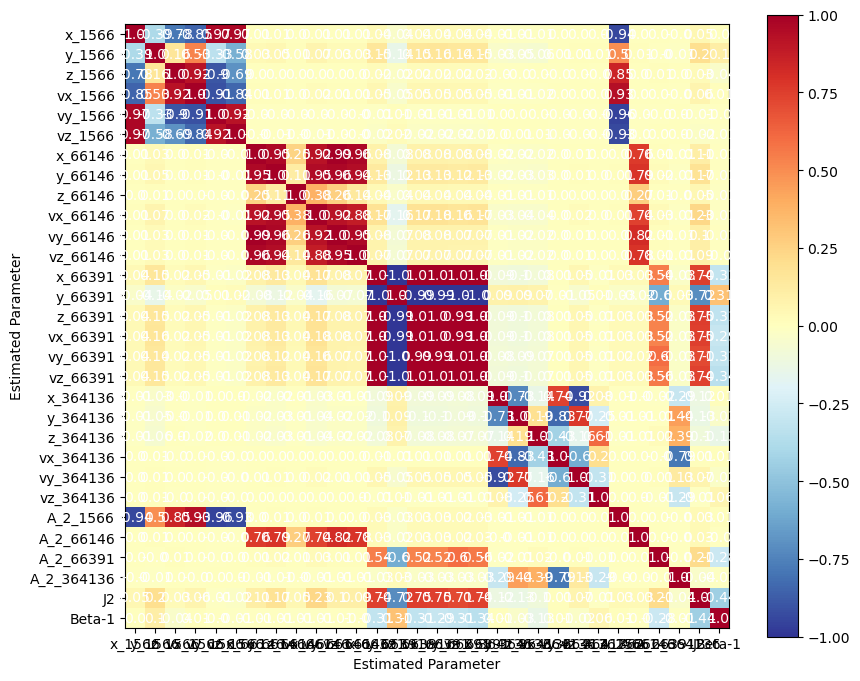

In [84]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

im = ax.imshow(correlations_occult_6, cmap=cm.RdYlBu_r, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)
ax.set_yticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)

# add numbers to each of the boxes
for i in range(len(estimated_param_names)):
    for j in range(len(estimated_param_names)):
        text = ax.text(
            j, i, round(correlations_occult_6[i, j], 2), ha="center", va="center", color="w"
        )

cb = plt.colorbar(im)

ax.set_xlabel("Estimated Parameter")
ax.set_ylabel("Estimated Parameter")

#fig.suptitle(f"Correlations for estimated parameters for {target_name}")

fig.set_tight_layout(True)


In [85]:
# covariance_output_occult.correlations
print(covariance_output_occult_4.covariance[-1])
print()

print("Formal errors before stellar occultations")
print(covariance_output.formal_errors)
print('---------------------------------------------')
print("Formal errors after stellar occultations")
print(covariance_output_occult.formal_errors)
print("Formal errors after 2 asteroids occultating")
print(covariance_output_occult_2.formal_errors)
print("Formal errors after 3 asteroids occultating")
print(covariance_output_occult_3.formal_errors)
print("Formal errors after 4 asteroids occultating")
print(covariance_output_occult_4.formal_errors)
print("Formal errors after 5 asteroids occultating")
print(covariance_output_occult_5.formal_errors)
print("Formal errors after 6 asteroids occultating")
print(covariance_output_occult_6.formal_errors)

diff_covariance_6 = covariance_output.formal_errors - covariance_output_occult_6.formal_errors

print()
print('----------------------------------------------')
# print('Using NOISE of 1*10**3 mas')
print("Difference between formal errors before and after 5 stellar occultations are added")
print(diff_covariance_6)

[ 5.57825650e-05  6.38895380e-04 -5.45209745e-04  1.95515541e-11
 -5.55382527e-12 -2.87502737e-11 -9.28105230e-05 -4.05375216e-05
 -3.73036823e-05 -1.28344689e-11 -3.15940859e-11 -4.24916671e-13
 -4.88908971e-03  4.96144448e-03 -3.08727148e-03 -6.70787863e-09
 -7.50527778e-09 -6.12130741e-09  4.98947859e-05 -3.64130364e-04
 -1.00413127e-03  4.25092755e-11 -4.45188038e-11  4.43455421e-11
  4.49144569e-22 -6.93294234e-23 -6.90197600e-21 -4.05724336e-22
 -2.08027997e-09  1.58744801e-13]

Formal errors before stellar occultations
[6.19753090e+04 1.56056393e+04 3.57081742e+04 3.67987572e-03
 8.03822543e-03 5.40709923e-03 4.40738626e+04 1.72275701e+04
 1.06833140e+04 3.43064318e-03 1.42381670e-02 5.43707340e-03
 4.25747054e+04 4.34200195e+04 2.67840951e+04 6.42033957e-02
 6.63709273e-02 4.66684249e-02 1.45640146e+04 2.61720551e+04
 1.89931418e+04 7.17747174e-03 4.68715067e-03 1.96463909e-03
 1.35522655e-13 7.32220343e-14 8.48145420e-14 6.86150503e-14
 1.18945221e-02 4.00979155e-07]
---------

## 7th stellar occultation

In [86]:
# 7. Simulate the observations and add the weights

times_list_7_occult = [time_1_7_occult]

tracking_ast_link_definition_7_occult, sigma_noise_rad_7_occult, simulated_observations_7_occult = simulate_stellar_occultation("66391", "TrackingStation", times_list_7_occult)

# Create the weights

weight1_7_occult = 1.0 / (sigma_noise_rad_7_occult ** 2)
weight2_7_occult = 1.0 / (sigma_noise_rad_7_occult)**2      # larger than the 1st weight
# weight3 = 1.0 / (sigma_noise_rad * 2)**2        # much smaller of the 1st weight


# Set weights for the entire collection
tabulated_weights_7_occult = np.array([
    weight1_7_occult, weight1_7_occult,   # RA1, DEC1
    # weight2, weight2,   # RA2, DEC2
    # weight3, weight3    # RA3, DEC3
])

print(tabulated_weights_7_occult.shape)

# Add the weights
simulated_observations_7_occult.set_tabulated_weights(tabulated_weights_7_occult)


# 8. Merge together with previous observations

combined_observation_collection_7_occult = observations.merge_observation_collections(
        [combined_observation_collection_6_occult, simulated_observations_7_occult]
    )


# 9. Create the links

occultation_links = [
    one_way_tracking_ast_link_definition,
    tracking_ast_link_definition_2_occult,
    tracking_ast_link_definition_3_occult,
    tracking_ast_link_definition_4_occult,
    tracking_ast_link_definition_5_occult,
    tracking_ast_link_definition_6_occult,
    tracking_ast_link_definition_7_occult
]

observation_settings_list_comb_7_occult = [
    observable_models_setup.model_settings.angular_position(link)
    for link in list(link_list) + occultation_links
]

estimator_stell_occult_7 = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list_comb_7_occult,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

# 10. Analyse covariance, correlations etc. with the new simulated data

# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input_occult_7 = estimation_analysis.CovarianceAnalysisInput(combined_observation_collection_7_occult)
covariance_output_occult_7 = estimator_stell_occult_7.compute_covariance(covariance_input_occult_7)

correlations_occult_7 = covariance_output_occult_7.correlations

(2,)
Calculating residuals and partials 13914


## 8th occultation

In [87]:
# 7. Simulate the observations and add the weights

times_list_8_occult = [time_1_8_occult]

tracking_ast_link_definition_8_occult, sigma_noise_rad_8_occult, simulated_observations_8_occult = simulate_stellar_occultation("66391", "TrackingStation", times_list_8_occult)

# Create the weights

weight1_8_occult = 1.0 / (sigma_noise_rad_8_occult ** 2)
weight2_8_occult = 1.0 / (sigma_noise_rad_8_occult)**2      # larger than the 1st weight
# weight3 = 1.0 / (sigma_noise_rad * 2)**2        # much smaller of the 1st weight


# Set weights for the entire collection
tabulated_weights_8_occult = np.array([
    weight1_8_occult, weight1_8_occult,   # RA1, DEC1
    # weight2, weight2,   # RA2, DEC2
    # weight3, weight3    # RA3, DEC3
])

print(tabulated_weights_8_occult.shape)

# Add the weights
simulated_observations_8_occult.set_tabulated_weights(tabulated_weights_8_occult)


# 8. Merge together with previous observations

combined_observation_collection_8_occult = observations.merge_observation_collections(
        [combined_observation_collection_7_occult, simulated_observations_8_occult]
    )


# 9. Create the links

occultation_links = [
    one_way_tracking_ast_link_definition,
    tracking_ast_link_definition_2_occult,
    tracking_ast_link_definition_3_occult,
    tracking_ast_link_definition_4_occult,
    tracking_ast_link_definition_5_occult,
    tracking_ast_link_definition_6_occult,
    tracking_ast_link_definition_7_occult,
    tracking_ast_link_definition_8_occult
]

observation_settings_list_comb_8_occult = [
    observable_models_setup.model_settings.angular_position(link)
    for link in list(link_list) + occultation_links
]

estimator_stell_occult_8 = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list_comb_8_occult,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

# 10. Analyse covariance, correlations etc. with the new simulated data

# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input_occult_8 = estimation_analysis.CovarianceAnalysisInput(combined_observation_collection_8_occult)
covariance_output_occult_8 = estimator_stell_occult_8.compute_covariance(covariance_input_occult_8)

correlations_occult_8 = covariance_output_occult_8.correlations

(2,)
Calculating residuals and partials 13916


## 9th occultation

In [88]:
# 7. Simulate the observations and add the weights

times_list_9_occult = [time_1_9_occult]

tracking_ast_link_definition_9_occult, sigma_noise_rad_9_occult, simulated_observations_9_occult = simulate_stellar_occultation("66391", "TrackingStation", times_list_9_occult)

# Create the weights

weight1_9_occult = 1.0 / (sigma_noise_rad_9_occult ** 2)
weight2_9_occult = 1.0 / (sigma_noise_rad_9_occult)**2      # larger than the 1st weight
# weight3 = 1.0 / (sigma_noise_rad * 2)**2        # much smaller of the 1st weight


# Set weights for the entire collection
tabulated_weights_9_occult = np.array([
    weight1_9_occult, weight1_9_occult,   # RA1, DEC1
    # weight2, weight2,   # RA2, DEC2
    # weight3, weight3    # RA3, DEC3
])

print(tabulated_weights_9_occult.shape)

# Add the weights
simulated_observations_9_occult.set_tabulated_weights(tabulated_weights_9_occult)


# 8. Merge together with previous observations

combined_observation_collection_9_occult = observations.merge_observation_collections(
        [combined_observation_collection_8_occult, simulated_observations_9_occult]
    )


# 9. Create the links

occultation_links = [
    one_way_tracking_ast_link_definition,
    tracking_ast_link_definition_2_occult,
    tracking_ast_link_definition_3_occult,
    tracking_ast_link_definition_4_occult,
    tracking_ast_link_definition_5_occult,
    tracking_ast_link_definition_6_occult,
    tracking_ast_link_definition_7_occult,
    tracking_ast_link_definition_8_occult,
    tracking_ast_link_definition_9_occult
]

observation_settings_list_comb_9_occult = [
    observable_models_setup.model_settings.angular_position(link)
    for link in list(link_list) + occultation_links
]

estimator_stell_occult_9 = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list_comb_9_occult,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

# 10. Analyse covariance, correlations etc. with the new simulated data

# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input_occult_9 = estimation_analysis.CovarianceAnalysisInput(combined_observation_collection_9_occult)
covariance_output_occult_9 = estimator_stell_occult_9.compute_covariance(covariance_input_occult_9)

correlations_occult_9 = covariance_output_occult_9.correlations

(2,)
Calculating residuals and partials 13918


## 10th occultation

In [89]:
# 7. Simulate the observations and add the weights

times_list_10_occult = [time_1_10_occult]

tracking_ast_link_definition_10_occult, sigma_noise_rad_10_occult, simulated_observations_10_occult = simulate_stellar_occultation("66391", "TrackingStation", times_list_10_occult)

# Create the weights

weight1_10_occult = 1.0 / (sigma_noise_rad_10_occult ** 2)
weight2_10_occult = 1.0 / (sigma_noise_rad_10_occult)**2      # larger than the 1st weight
# weight3 = 1.0 / (sigma_noise_rad * 2)**2        # much smaller of the 1st weight


# Set weights for the entire collection
tabulated_weights_10_occult = np.array([
    weight1_10_occult, weight1_10_occult,   # RA1, DEC1
    # weight2, weight2,   # RA2, DEC2
    # weight3, weight3    # RA3, DEC3
])

print(tabulated_weights_10_occult.shape)

# Add the weights
simulated_observations_10_occult.set_tabulated_weights(tabulated_weights_10_occult)


# 8. Merge together with previous observations

combined_observation_collection_10_occult = observations.merge_observation_collections(
        [combined_observation_collection_9_occult, simulated_observations_10_occult]
    )


# 9. Create the links

occultation_links = [
    one_way_tracking_ast_link_definition,
    tracking_ast_link_definition_2_occult,
    tracking_ast_link_definition_3_occult,
    tracking_ast_link_definition_4_occult,
    tracking_ast_link_definition_5_occult,
    tracking_ast_link_definition_6_occult,
    tracking_ast_link_definition_7_occult,
    tracking_ast_link_definition_8_occult,
    tracking_ast_link_definition_9_occult,
    tracking_ast_link_definition_10_occult
]

observation_settings_list_comb_10_occult = [
    observable_models_setup.model_settings.angular_position(link)
    for link in list(link_list) + occultation_links
]

estimator_stell_occult_10 = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list_comb_10_occult,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

# 10. Analyse covariance, correlations etc. with the new simulated data

# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input_occult_10 = estimation_analysis.CovarianceAnalysisInput(combined_observation_collection_10_occult)
covariance_output_occult_10 = estimator_stell_occult_10.compute_covariance(covariance_input_occult_10)

correlations_occult_10 = covariance_output_occult_10.correlations

(2,)
Calculating residuals and partials 13920


In [90]:
# covariance_output_occult.correlations
print(covariance_output_occult_4.covariance[-1])
print()

print("Formal errors before stellar occultations")
print(covariance_output.formal_errors)
print('---------------------------------------------')
print("Formal errors after stellar occultations")
print(covariance_output_occult.formal_errors)
print("Formal errors after 2 asteroids occultating")
print(covariance_output_occult_2.formal_errors)
print("Formal errors after 3 asteroids occultating")
print(covariance_output_occult_3.formal_errors)
print("Formal errors after 4 asteroids occultating")
print(covariance_output_occult_4.formal_errors)
print("Formal errors after 5 asteroids occultating")
print(covariance_output_occult_5.formal_errors)
print("Formal errors after 6 asteroids occultating")
print(covariance_output_occult_6.formal_errors)
print("Formal errors after 10 asteroids occultating")
print(covariance_output_occult_10.formal_errors)

diff_covariance_10 = covariance_output.formal_errors - covariance_output_occult_10.formal_errors

print()
print('----------------------------------------------')
# print('Using NOISE of 1*10**3 mas')
print("Difference between formal errors before and after 10 stellar occultations are added")
print(diff_covariance_10)

[ 5.57825650e-05  6.38895380e-04 -5.45209745e-04  1.95515541e-11
 -5.55382527e-12 -2.87502737e-11 -9.28105230e-05 -4.05375216e-05
 -3.73036823e-05 -1.28344689e-11 -3.15940859e-11 -4.24916671e-13
 -4.88908971e-03  4.96144448e-03 -3.08727148e-03 -6.70787863e-09
 -7.50527778e-09 -6.12130741e-09  4.98947859e-05 -3.64130364e-04
 -1.00413127e-03  4.25092755e-11 -4.45188038e-11  4.43455421e-11
  4.49144569e-22 -6.93294234e-23 -6.90197600e-21 -4.05724336e-22
 -2.08027997e-09  1.58744801e-13]

Formal errors before stellar occultations
[6.19753090e+04 1.56056393e+04 3.57081742e+04 3.67987572e-03
 8.03822543e-03 5.40709923e-03 4.40738626e+04 1.72275701e+04
 1.06833140e+04 3.43064318e-03 1.42381670e-02 5.43707340e-03
 4.25747054e+04 4.34200195e+04 2.67840951e+04 6.42033957e-02
 6.63709273e-02 4.66684249e-02 1.45640146e+04 2.61720551e+04
 1.89931418e+04 7.17747174e-03 4.68715067e-03 1.96463909e-03
 1.35522655e-13 7.32220343e-14 8.48145420e-14 6.86150503e-14
 1.18945221e-02 4.00979155e-07]
---------

### Checking what happens when I get several occultations of ONE asteroid

In [119]:

# time_2 = 17 * one_year_seconds + 10
# time_3 = 17 * one_year_seconds + 20
# time_4 = 17 * one_year_seconds + 30
# time_5 = 17 * one_year_seconds + 40
# time_6 = 17 * one_year_seconds + 50

# time_7 = 17 * one_year_seconds + 60
# time_8 = 17 * one_year_seconds + 70
# time_9 = 17 * one_year_seconds + 80
# time_10 = 17 * one_year_seconds + 90

time_2 = 17 * one_year_seconds + 10
time_3 = 17 * one_year_seconds + 5 * 20
time_4 = 17 * one_year_seconds + 5 * 30
time_5 = 17 * one_year_seconds + 5 * 40
time_6 = 17 * one_year_seconds + 5 * 50

time_7 = 17 * one_year_seconds + 5 * 60
time_8 = 17 * one_year_seconds + 5 * 70
time_9 = 17 * one_year_seconds + 5 * 80
time_10 = 17 * one_year_seconds + 5 * 90

# observation_times = [time_1, time_2, time_3]
# observation_times = [time_1]
times_list_ONE_occult = [time_1, time_2, time_3, time_4, time_5, time_6, time_7, time_8, time_9, time_10]

In [120]:
# 7. Simulate the observations and add the weights

tracking_ast_link_definition_ONE_occult, sigma_noise_rad_ONE_occult, simulated_observations_ONE_occult = simulate_stellar_occultation("66391", "TrackingStation", times_list_ONE_occult)

# Create the weights 

weight1_ONE_occult = 1.0 / (sigma_noise_rad_ONE_occult ** 2)
weight2_ONE_occult = 1.0 / (sigma_noise_rad_ONE_occult ** 2)      # larger than the 1st weight
# weight3 = 1.0 / (sigma_noise_rad * 2)**2        # much smaller of the 1st weight


# Set weights for the entire collection
tabulated_weights_ONE_occult = np.array([
    weight1_ONE_occult, weight1_ONE_occult,   # RA1, DEC1
    weight1_ONE_occult, weight1_ONE_occult,   # RA1, DEC1
    weight1_ONE_occult, weight1_ONE_occult,   # RA1, DEC1
    weight1_ONE_occult, weight1_ONE_occult,   # RA1, DEC1
    weight1_ONE_occult, weight1_ONE_occult,   # RA1, DEC1
    weight1_ONE_occult, weight1_ONE_occult,   # RA1, DEC1
    weight1_ONE_occult, weight1_ONE_occult,   # RA1, DEC1
    weight1_ONE_occult, weight1_ONE_occult,   # RA1, DEC1
    weight1_ONE_occult, weight1_ONE_occult,   # RA1, DEC1
    weight1_ONE_occult, weight1_ONE_occult,   # RA1, DEC1
])

print(tabulated_weights_ONE_occult.shape)

# Add the weights
simulated_observations_ONE_occult.set_tabulated_weights(tabulated_weights_ONE_occult)

(20,)


In [121]:
# 8. Merge together with previous observations

combined_observation_collection_ONE_occult = observations.merge_observation_collections(
        [observation_collection, simulated_observations_ONE_occult]
    )

In [122]:
# 9. Combine the Observation Models for MPC and Stellar Occultations 
# So that it can be used in the estimaotr
# Otherwise the bodies won't be found when creating the covariance_output
 
observation_settings_list_comb_ONE_occult = []

# MPC
for link in link_list:
    observation_settings_list_comb_ONE_occult.append(
        observable_models_setup.model_settings.angular_position(link)
    )

# 1st occultation
observation_settings_list_comb_ONE_occult.append(
    observable_models_setup.model_settings.angular_position(tracking_ast_link_definition_ONE_occult)
)

# Define a new estimator
estimator_stell_occult_ONE = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list_comb_ONE_occult,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

In [123]:
# 10. Analyse covariance, correlations etc. with the new simulated data

# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input_occult_ONE = estimation_analysis.CovarianceAnalysisInput(combined_observation_collection_ONE_occult)
covariance_output_occult_ONE = estimator_stell_occult_ONE.compute_covariance(covariance_input_occult_ONE)

correlations_occult_ONE = covariance_output_occult_ONE.correlations

Calculating residuals and partials 13920


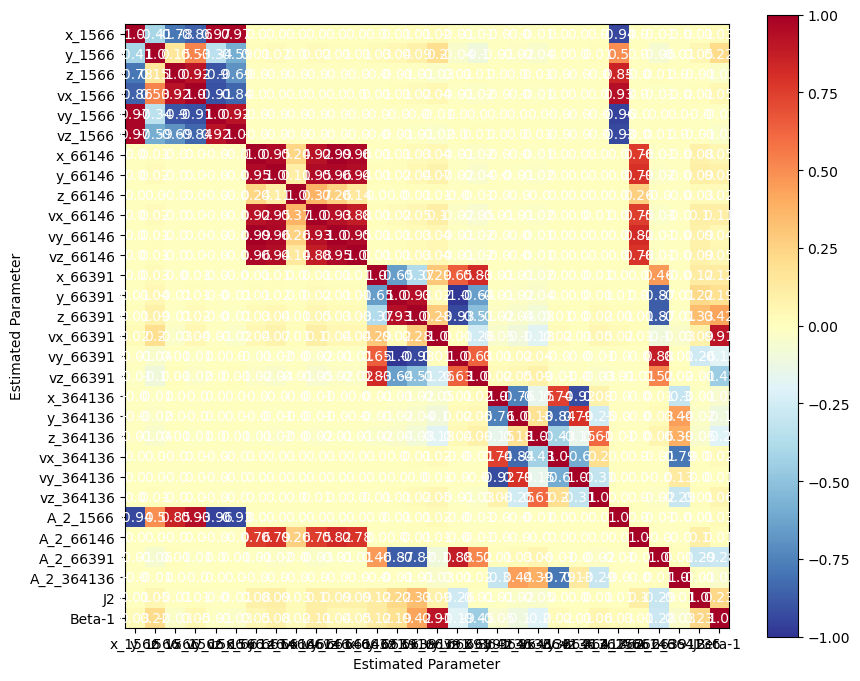

In [124]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

im = ax.imshow(correlations_occult_ONE, cmap=cm.RdYlBu_r, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)
ax.set_yticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)

# add numbers to each of the boxes
for i in range(len(estimated_param_names)):
    for j in range(len(estimated_param_names)):
        text = ax.text(
            j, i, round(correlations_occult_ONE[i, j], 2), ha="center", va="center", color="w"
        )

cb = plt.colorbar(im)

ax.set_xlabel("Estimated Parameter")
ax.set_ylabel("Estimated Parameter")

#fig.suptitle(f"Correlations for estimated parameters for {target_name}")

fig.set_tight_layout(True)


In [125]:
# covariance_output_occult.correlations
print(covariance_output_occult_ONE.covariance[-1])
print()

print("Formal errors before stellar occultations")
print(covariance_output.formal_errors)
print('---------------------------------------------')
print("Formal errors after stellar occultations")
print(covariance_output_occult.formal_errors)
print("Formal errors after 2 asteroids occultating")
print(covariance_output_occult_2.formal_errors)
print("Formal errors after 3 asteroids occultating")
print(covariance_output_occult_3.formal_errors)
print("Formal errors after 4 asteroids occultating")
print(covariance_output_occult_4.formal_errors)
# print("Formal errors after 5 asteroids occultating")
# print(covariance_output_occult_5.formal_errors)
# print("Formal errors after 6 asteroids occultating")
# print(covariance_output_occult_6.formal_errors)
print("Formal errors after ONE asteroid occultating ten times")
print(covariance_output_occult_ONE.formal_errors)

diff_covariance_ONE = covariance_output.formal_errors - covariance_output_occult_ONE.formal_errors

print()
print('----------------------------------------------')
# print('Using NOISE of 1*10**3 mas')
print("Difference between formal errors before and after 10 stellar occultations of asteroid 66391 are added")
print(diff_covariance_ONE)

[ 5.93397549e-04  1.18537956e-03 -3.84033967e-04  6.08251483e-11
 -2.29564695e-11 -5.09547134e-11  7.45395237e-04  4.85704087e-04
  6.07059052e-05  1.25762374e-10  2.20431841e-10  9.07038295e-11
  6.07330300e-05  2.51684945e-04  1.00884365e-09  4.18739244e-10
 -3.74287265e-10 -5.01730472e-10 -2.55076093e-04 -9.63778159e-04
 -1.33442585e-03  5.25721291e-11  1.05098926e-11  3.95554827e-11
  1.28055405e-21  3.77852645e-22 -4.95850639e-21 -8.44818487e-22
  1.77506241e-14  1.27253036e-13]

Formal errors before stellar occultations
[6.19753090e+04 1.56056393e+04 3.57081742e+04 3.67987572e-03
 8.03822543e-03 5.40709923e-03 4.40738626e+04 1.72275701e+04
 1.06833140e+04 3.43064318e-03 1.42381670e-02 5.43707340e-03
 4.25747054e+04 4.34200195e+04 2.67840951e+04 6.42033957e-02
 6.63709273e-02 4.66684249e-02 1.45640146e+04 2.61720551e+04
 1.89931418e+04 7.17747174e-03 4.68715067e-03 1.96463909e-03
 1.35522655e-13 7.32220343e-14 8.48145420e-14 6.86150503e-14
 1.18945221e-02 4.00979155e-07]
---------

In [126]:
print(observation_collection.concatenated_observations.shape)

print(simulated_observations_10_occult.concatenated_observations.shape)

print(combined_observation_collection_10_occult.concatenated_observations.shape)

(13900,)
(2,)
(13920,)


### Plotting the errors (and decrease in errors)

In [127]:
# Extract each beta and j2

j2_error_baseline = covariance_output.formal_errors[-1]
beta_error_baseline = covariance_output.formal_errors[-2]

j2_error_occ1 = covariance_output_occult.formal_errors[-1]
beta_error_occ1 = covariance_output_occult.formal_errors[-2]

j2_error_occ2 = covariance_output_occult_2.formal_errors[-1]
beta_error_occ2 = covariance_output_occult_2.formal_errors[-2]

j2_error_occ3 = covariance_output_occult_3.formal_errors[-1]
beta_error_occ3 = covariance_output_occult_3.formal_errors[-2]

j2_error_occ4 = covariance_output_occult_4.formal_errors[-1]
beta_error_occ4 = covariance_output_occult_4.formal_errors[-2]

j2_error_occ5 = covariance_output_occult_5.formal_errors[-1]
beta_error_occ5 = covariance_output_occult_5.formal_errors[-2]

j2_error_occ6 = covariance_output_occult_6.formal_errors[-1]
beta_error_occ6 = covariance_output_occult_6.formal_errors[-2]

j2_error_occ7 = covariance_output_occult_7.formal_errors[-1]
beta_error_occ7 = covariance_output_occult_7.formal_errors[-2]

j2_error_occ8 = covariance_output_occult_8.formal_errors[-1]
beta_error_occ8 = covariance_output_occult_8.formal_errors[-2]

j2_error_occ9 = covariance_output_occult_9.formal_errors[-1]
beta_error_occ9 = covariance_output_occult_9.formal_errors[-2]

j2_error_occ10 = covariance_output_occult_10.formal_errors[-1]
beta_error_occ10 = covariance_output_occult_10.formal_errors[-2]

# For several occultations of ONE asteroid

j2_error_occONE = covariance_output_occult_ONE.formal_errors[-1]
beta_error_occONE = covariance_output_occult_ONE.formal_errors[-2]


In [128]:
# Relative formal errors

j2_nominal = 2.2e-7
beta_nominal = 1.0

j2_relative = np.array([
    j2_error_baseline,
    j2_error_occ1,
    j2_error_occ2,
    j2_error_occ3,
    j2_error_occ4,
    j2_error_occ5,
    j2_error_occ6,
    j2_error_occ7,
    j2_error_occ8,
    j2_error_occ9,
    j2_error_occ10
]) / j2_error_baseline

beta_relative = np.array([
    beta_error_baseline,
    beta_error_occ1,
    beta_error_occ2,
    beta_error_occ3,
    beta_error_occ4,
    beta_error_occ5,
    beta_error_occ6,
    beta_error_occ7,
    beta_error_occ8,
    beta_error_occ9,
    beta_error_occ10
]) / beta_error_baseline

In [130]:
print("Fractional decrease of beta for 10 occultations")
print(beta_relative)
print("Fractional decrease of J2 for 10 occultations")
print(j2_relative)

Fractional decrease of beta for 10 occultations
[1.         0.98818183 0.98804169 0.98799427 0.98798297 0.9879662
 0.98795742 0.98794934 0.98791698 0.98791235 0.98791254]
Fractional decrease of J2 for 10 occultations
[1.         0.99371794 0.99366318 0.99364465 0.99363747 0.99363144
 0.99362782 0.99362492 0.99361841 0.99361676 0.99361611]


In [132]:
beta_nominal = 1.0
j2_nominal = 2.2e-7

verma_beta_sigma = 5.6 * 10**(-4)
verma_J2_sigma = 2.7 * 10**(-8)

beta_errors_N_ast = [
    covariance_output.formal_errors[-2],
    covariance_output_occult.formal_errors[-2],
    covariance_output_occult_2.formal_errors[-2],
    covariance_output_occult_3.formal_errors[-2],
    covariance_output_occult_4.formal_errors[-2],
    covariance_output_occult_5.formal_errors[-2],
    covariance_output_occult_6.formal_errors[-2],
    covariance_output_occult_7.formal_errors[-2],
    covariance_output_occult_8.formal_errors[-2],
    covariance_output_occult_9.formal_errors[-2],
    covariance_output_occult_10.formal_errors[-2]
    # verma_beta_sigma
]

j2_errors_N_ast = [
    covariance_output.formal_errors[-1],
    covariance_output_occult.formal_errors[-1],
    covariance_output_occult_2.formal_errors[-1],
    covariance_output_occult_3.formal_errors[-1],
    covariance_output_occult_4.formal_errors[-1],
    covariance_output_occult_5.formal_errors[-1],
    covariance_output_occult_6.formal_errors[-1],
    covariance_output_occult_7.formal_errors[-1],
    covariance_output_occult_8.formal_errors[-1],
    covariance_output_occult_9.formal_errors[-1],
    covariance_output_occult_10.formal_errors[-1]
    # verma_J2_sigma
]

labels_N_ast = [
    "0 occult.",
    "1 occult.",
    "2 occult.",
    "3 occult.",
    "4 occult.",
    "5 occult.",
    "6 occult.",
    "7 occult.",
    "8 occult.",
    "9 occult.",
    "10 occult."
    # "Verma et al"
]

# Adding several occultations for ONE asteroid

beta_errors_N_occ = [
    covariance_output.formal_errors[-2],
    covariance_output_occult_ONE.formal_errors[-2]
    # verma_beta_sigma
]

j2_errors_N_occ = [
    covariance_output.formal_errors[-1],
    covariance_output_occult_ONE.formal_errors[-1]
    # verma_J2_sigma
]

labels_N_occ = [
    "0 occult.",
    "Four occultations of asteroid 66391"
    # "Verma et al"
]

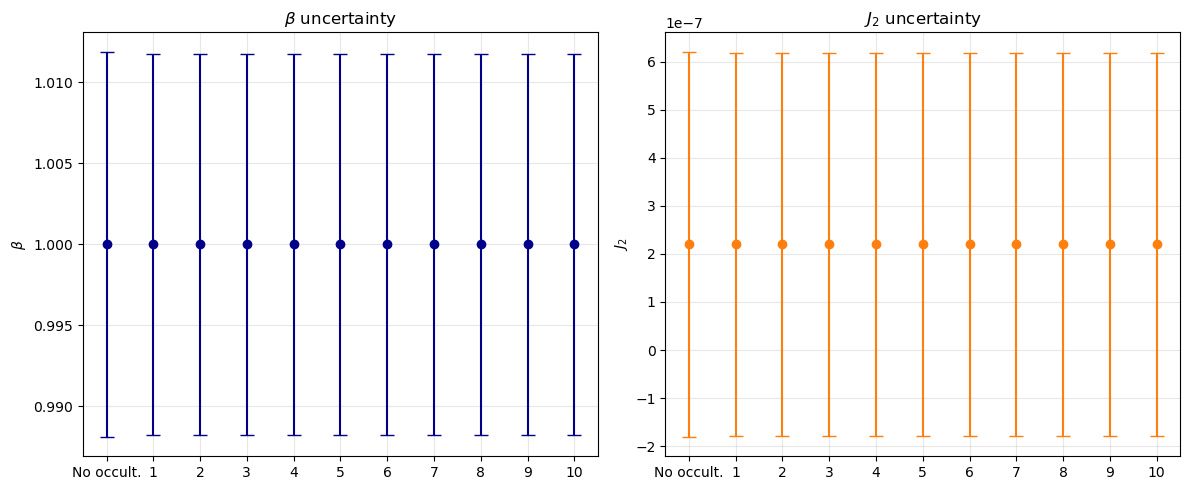

In [133]:
fig, axs = plt.subplots(1, 2, figsize=(12,5))

# Beta
axs[0].errorbar(
    n_occultations,
    [beta_nominal]*len(beta_errors_N_ast),
    yerr=beta_errors_N_ast,
    fmt='o',
    capsize=5,
    color='darkblue'
)

axs[0].grid(True, alpha=0.3)
axs[0].set_title(r'$\beta$ uncertainty')
axs[0].set_ylabel(r'$\beta$')

plt.grid(True)

# J2
axs[1].errorbar(
    n_occultations,
    [j2_nominal]*len(j2_errors_N_ast),
    yerr=j2_errors_N_ast,
    fmt='o',
    capsize=5,
    color='tab:orange'
)

axs[1].grid(True, alpha=0.3)
axs[1].set_title(r'$J_2$ uncertainty')
axs[1].set_ylabel(r'$J_2$')

plt.tight_layout()
plt.show()

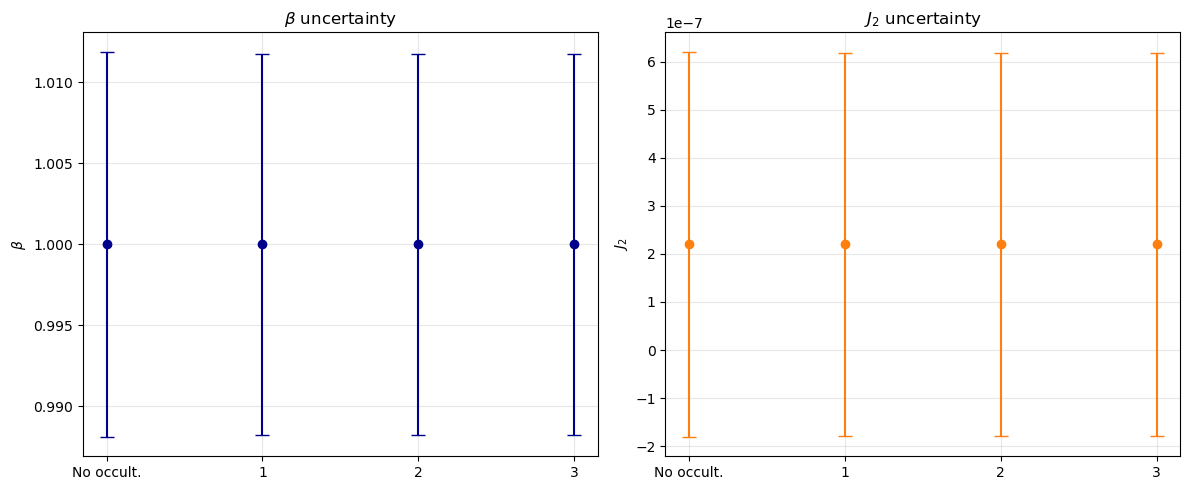

In [134]:
fig, axs = plt.subplots(1, 2, figsize=(12,5))

# Beta
axs[0].errorbar(
    n_occultations[:4],
    [beta_nominal]*4,
    yerr=beta_errors_N_ast[:4],
    fmt='o',
    capsize=5,
    color='darkblue'
)

axs[0].grid(True, alpha=0.3)
axs[0].set_title(r'$\beta$ uncertainty')
axs[0].set_ylabel(r'$\beta$')

plt.grid(True)

# J2
axs[1].errorbar(
    n_occultations[:4],
    [j2_nominal]*4,
    yerr=j2_errors_N_ast[:4],
    fmt='o',
    capsize=5,
    color='tab:orange'
)

axs[1].grid(True, alpha=0.3)
axs[1].set_title(r'$J_2$ uncertainty')
axs[1].set_ylabel(r'$J_2$')

plt.tight_layout()
plt.show()